# CPE 342 Machine Learning — Assignment 8: Clustering Basics
**Authors:**
- 67070501003 Guntee Doungmanee
- 67070501027 Natthawat Primsirikunawut
- 67070501042 Wisit Suwannao
- 67070501045 Supawit Marayat
- 67070501067 Polwarit Watthanahemmarat

**Instructor:** Dr. Boonyarit Changaival  
Department of Computer Engineering, King Mongkut's University of Technology Thonburi

---

## Lab Instruction

In this lab, you will learn how to implement and evaluate Prototype-based Clustering (K-Means) on various geometric manifolds and perform High-Dimensional Latent Subspace Clustering on the canonical Wine chemical dataset using PCA and K-Means.

The lab is divided into two main parts:
1. **Part I — K-Means Clustering on Synthetic Manifolds:** Apply K-Means across 4 distinct geometric datasets (Convex Blobs with Outliers, Concentric Circles, Interlocking Two Moons, and Anisotropic Multi-Density Blobs). Evaluate cluster validity via SSE Elbow curves, Silhouette Coefficients, Calinski-Harabasz index, Davies-Bouldin index, and investigate failure modes of linear Voronoi partitions on non-convex manifolds.
2. **Part II — High-Dimensional Latent Subspace Clustering on Wine Data:** Analyze $N=178$ wine observations across $p=13$ chemical constituents. Apply Z-Score Standardization, compute Spectral PCA decomposition, prove that $r=5$ Principal Components capture at least $80\%$ of total variance ($80.16\%$), identify dominant feature loadings on PC1 and PC2, cluster the 5D PC scores with optimal $K=3$, and map clusters to authentic Italian wine cultivars (Barolo, Grignolino, Barbera) with radar chemical profiling.

**Load necessary packages and apply custom configurations**

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['axes.grid'] = False

import seaborn as sns
sns.set_style("whitegrid", {'axes.grid': False})

%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import pandas as pd
import statsmodels as sm
import sklearn as sk
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from scipy.spatial.distance import cdist
from scipy import stats

def hopkins_statistic(X, n_samples=30, random_state=42):
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    m = min(n_samples, n // 2)
    sample_indices = rng.choice(n, size=m, replace=False)
    real_sample = X[sample_indices]
    mask = np.ones(n, dtype=bool)
    mask[sample_indices] = False
    rest_real = X[mask]
    w = np.min(cdist(real_sample, rest_real), axis=1)
    mins, maxs = np.min(X, axis=0), np.max(X, axis=0)
    synth = rng.uniform(mins, maxs, size=(m, d))
    u = np.min(cdist(synth, X), axis=1)
    return float(np.sum(u) / (np.sum(u) + np.sum(w)))

print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)
print('Seaborn version', sns.__version__)
print('Statsmodels version', sm.__version__)
print('Sklearn version', sk.__version__)

Numpy version 2.4.6
Pandas version 2.3.3
Seaborn version 0.13.2
Statsmodels version 0.15.0
Sklearn version 1.9.1


In [2]:
font_size = 13
params = {'legend.fontsize': 'large',
          'figure.figsize': (5, 4),
          'axes.labelsize': font_size,
          'axes.titlesize': font_size,
          'xtick.labelsize': font_size * 0.8,
          'ytick.labelsize': font_size * 0.8,
          'axes.titlepad': 25,
          'font.family': 'Sarabun',
          'font.sans-serif': ['Sarabun', 'TH Sarabun New', 'DejaVu Sans']}
plt.rcParams.update(params)

# <font color='orange'>Part I: K-means Clustering</font>

### Apply K-mean clustering to dataset 1

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [3]:
import os
from pathlib import Path

candidates = [
    Path('clustering-basics.xlsx'),
    Path('data/clustering-basics.xlsx'),
    Path('assignment/Assignment 8_Clustering_Basics/clustering-basics.xlsx'),
    Path('../clustering-basics.xlsx'),
    Path.cwd() / 'clustering-basics.xlsx',
    Path.cwd() / 'data/clustering-basics.xlsx',
    Path.cwd() / 'assignment/Assignment 8_Clustering_Basics/clustering-basics.xlsx',
]
EXCEL_PATH = next((str(p) for p in candidates if p.is_file()), 'clustering-basics.xlsx')

xl = pd.ExcelFile(EXCEL_PATH)
df_d1 = xl.parse('Dataset1')
X1 = df_d1[['X1', 'X2']].values

print(f"Dataset 1 Shape: {df_d1.shape}")
print("\nFirst 5 records of Dataset 1:")
print(df_d1.head())
print("\nSummary Statistics of Dataset 1:")
print(df_d1.describe().round(3))

h1 = hopkins_statistic(X1)
print(f"\nHopkins Statistic (H): {h1:.4f} (Strong Clustering Tendency, H > 0.75)")

Dataset 1 Shape: (600, 2)

First 5 records of Dataset 1:
         X1        X2
0 -1.180026 -0.750860
1 -1.488851 -0.714801
2 -0.828153 -0.916925
3  0.792955 -0.910485
4 -1.988658 -1.318758

Summary Statistics of Dataset 1:
            X1       X2
count  600.000  600.000
mean     0.398   -0.305
std      1.248    1.070
min     -2.079   -2.159
25%     -0.771   -1.141
50%      0.785   -0.716
75%      1.139    0.760
max     10.077    4.123

Hopkins Statistic (H): 0.9596 (Strong Clustering Tendency, H > 0.75)


In [4]:
d1_sse = {}
d1_sil = {}
d1_ch = {}

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X1)
    d1_sse[k] = km.inertia_
    if k >= 2:
        d1_sil[k] = silhouette_score(X1, km.labels_)
        d1_ch[k] = calinski_harabasz_score(X1, km.labels_)

d1_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d1_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d1_sil[k] for k in range(2, 11)],
    'Calinski-Harabasz': [d1_ch[k] for k in range(2, 11)]
})
print("Dataset 1 Clustering Evaluation Metrics:")
print(d1_metrics_df.to_string(index=False))

Dataset 1 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score  Calinski-Harabasz
            2     858.331585          0.507917         529.680805
            3     449.604175          0.625396         776.117969
            4     184.323583          0.646824        1545.886454
            5     160.688873          0.530433        1349.593082
            6     138.307767          0.426666        1271.504629
            7     119.248047          0.330243        1242.801800
            8     104.915019          0.338008        1220.255049
            9      91.131497          0.349350        1238.231504
           10      78.373913          0.355307        1288.317887


Text(0.5, 1.0, 'Elbow Method: Inertia vs K (Dataset 1)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Sum of Squared Errors (SSE)')

Text(0.5, 1.0, 'Silhouette Coefficient vs K (Dataset 1)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Mean Silhouette Score')

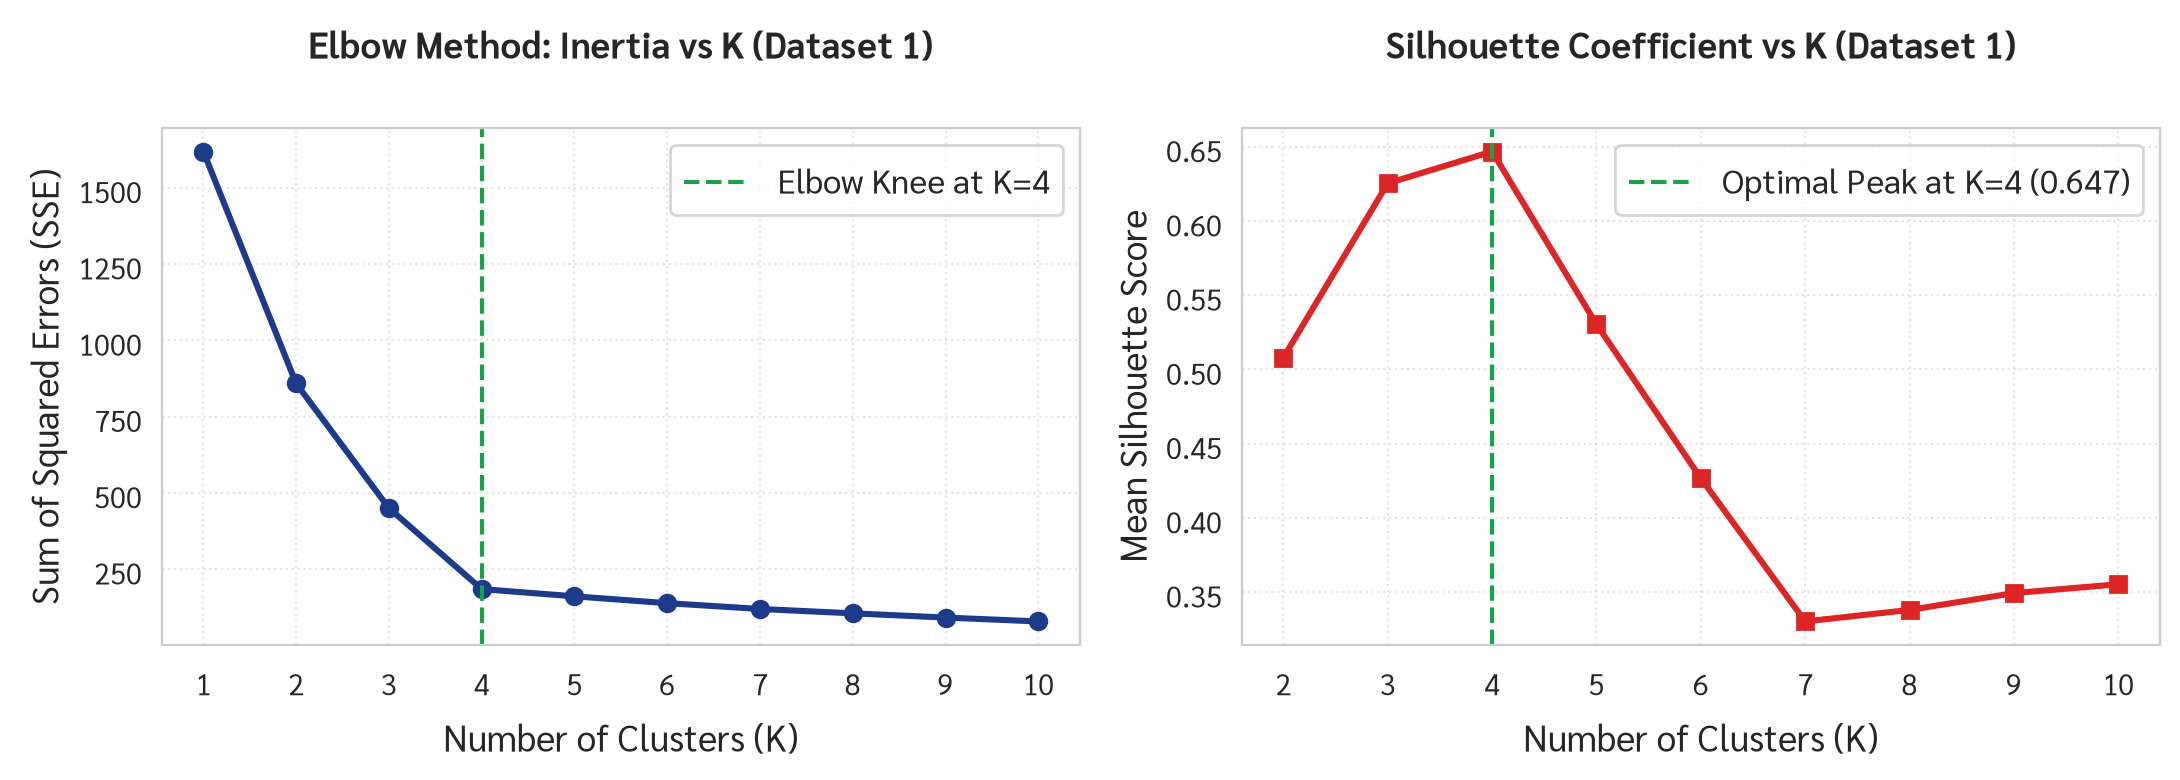

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Elbow Curve
axes[0].plot(list(d1_sse.keys()), list(d1_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2, markersize=6)
axes[0].axvline(x=4, color='#16A34A', linestyle='--', linewidth=1.5, label='Elbow Knee at K=4')
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 1)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Sum of Squared Errors (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(frameon=True)

# Silhouette Score Curve
axes[1].plot(list(d1_sil.keys()), list(d1_sil.values()), marker='s', color='#DC2626', linewidth=2.2, markersize=6)
axes[1].axvline(x=4, color='#16A34A', linestyle='--', linewidth=1.5, label='Optimal Peak at K=4 (0.647)')
axes[1].set_title('Silhouette Coefficient vs K (Dataset 1)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Dataset 1: K-Means Clustering (K=4, Isolating Outliers)')

Text(0.5, 0, 'Feature $X_1$')

Text(0, 0.5, 'Feature $X_2$')

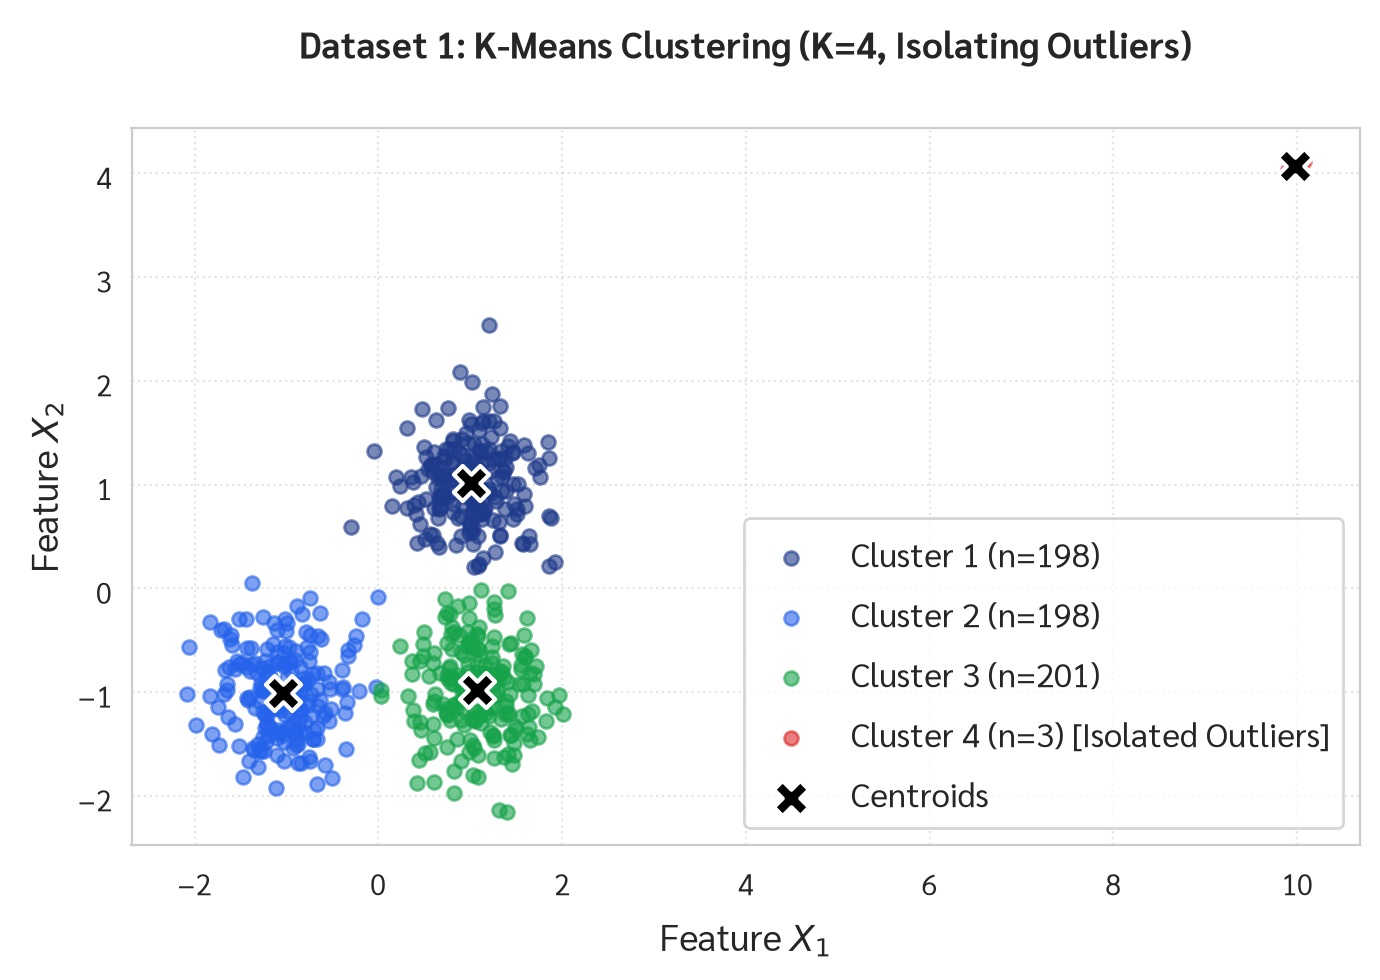

Optimal Cluster Count: K=4
Cluster Centroids:
[[ 1.004  1.011]
 [-1.036 -1.004]
 [ 1.071 -0.979]
 [ 9.972  4.067]]
Point count per cluster: {0: 198, 1: 198, 2: 201, 3: 3}


In [6]:
km1 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X1)
labels_d1 = km1.labels_
centers_d1 = km1.cluster_centers_

plt.figure(figsize=(7, 5))
colors = ['#1E3A8A', '#2563EB', '#16A34A', '#DC2626']
for c in range(4):
    mask = (labels_d1 == c)
    lbl = f'Cluster {c+1} (n={np.sum(mask)})'
    if c == 3:
        lbl += ' [Isolated Outliers]'
    plt.scatter(X1[mask, 0], X1[mask, 1], c=colors[c], s=25, alpha=0.6, label=lbl)

plt.scatter(centers_d1[:, 0], centers_d1[:, 1], c='black', marker='X', s=160, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.title('Dataset 1: K-Means Clustering (K=4, Isolating Outliers)', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K=4")
print(f"Cluster Centroids:\n{centers_d1.round(3)}")
print(f"Point count per cluster: {pd.Series(labels_d1).value_counts().sort_index().to_dict()}")

### Apply K-mean clustering to dataset 2

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [7]:
df_d2 = xl.parse('Dataset2')
X2 = df_d2[['X1', 'X2']].values

d2_sse = {}
d2_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2)
    d2_sse[k] = km.inertia_
    if k >= 2:
        d2_sil[k] = silhouette_score(X2, km.labels_)

d2_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d2_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d2_sil[k] for k in range(2, 11)]
})
print("Dataset 2 Clustering Evaluation Metrics:")
print(d2_metrics_df.to_string(index=False))

Dataset 2 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2     378.804520          0.265636
            3     275.168110          0.386493
            4     190.619078          0.473382
            5     128.315749          0.520031
            6      94.962989          0.537451
            7      78.421639          0.533349
            8      65.694269          0.422343
            9      54.860092          0.421748
           10      47.412637          0.420865


Text(0.5, 1.0, 'Elbow Method: Inertia vs K (Dataset 2)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Inertia (SSE)')

Text(0.5, 1.0, 'Silhouette Coefficient vs K (Dataset 2)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Mean Silhouette Score')

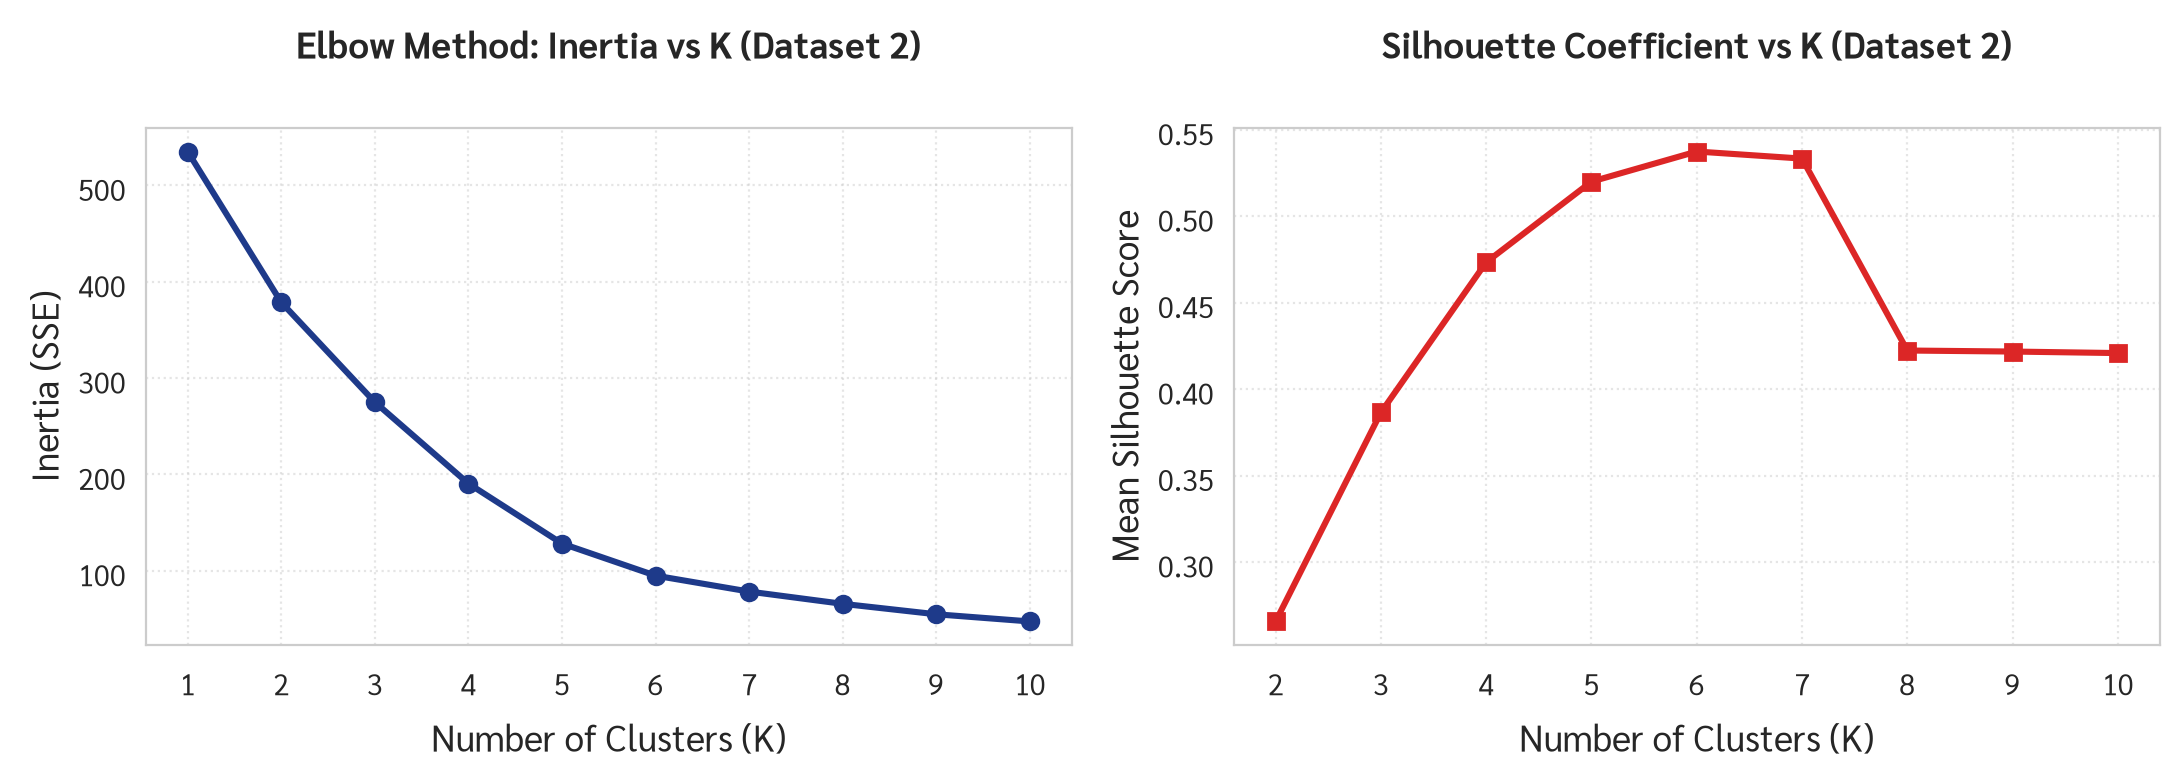

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d2_sse.keys()), list(d2_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 2)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d2_sil.keys()), list(d2_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 2)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

Text(0.5, 1.0, 'Dataset 2: K-Means (K=2) — Voronoi Failure')

Text(0.5, 0, 'Feature $X_1$')

Text(0, 0.5, 'Feature $X_2$')

Text(0.5, 1.0, 'Dataset 2: K-Means (K=6) — Pie-slice Partition')

Text(0.5, 0, 'Feature $X_1$')

Text(0, 0.5, 'Feature $X_2$')

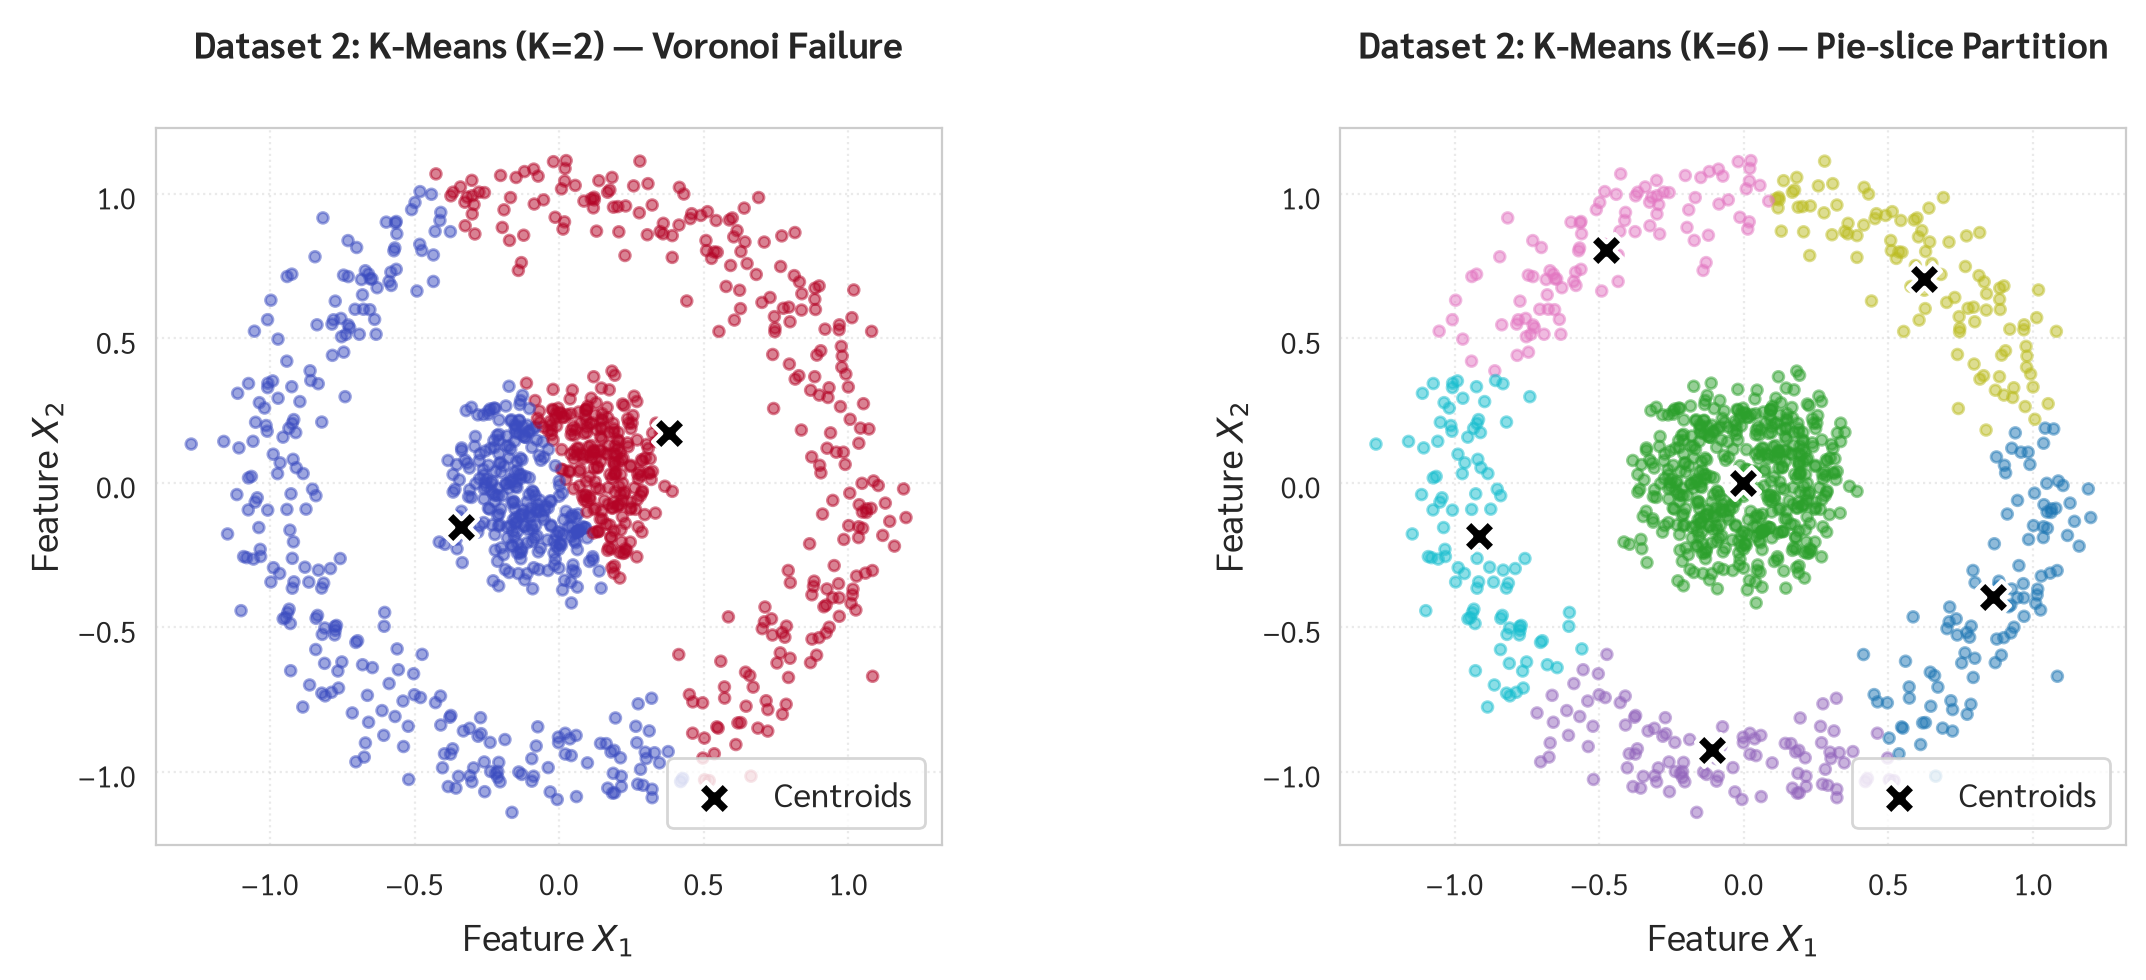

Limitation Note: K-Means assumes convex clusters separated by linear hyperplanes.
For concentric rings, K-Means inherently fails to separate inner vs outer rings.


In [9]:
km2_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X2)
km2_k6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K=2
axes[0].scatter(X2[:, 0], X2[:, 1], c=km2_k2.labels_, cmap='coolwarm', s=15, alpha=0.5)
axes[0].scatter(km2_k2.cluster_centers_[:, 0], km2_k2.cluster_centers_[:, 1], c='black', marker='X', s=140, edgecolors='white', linewidth=1.5, label='Centroids')
axes[0].set_title('Dataset 2: K-Means (K=2) — Voronoi Failure', fontweight='bold')
axes[0].set_xlabel('Feature $X_1$')
axes[0].set_ylabel('Feature $X_2$')
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle=':', alpha=0.4)
axes[0].legend(loc='lower right', frameon=True)

# K=6
axes[1].scatter(X2[:, 0], X2[:, 1], c=km2_k6.labels_, cmap='tab10', s=15, alpha=0.5)
axes[1].scatter(km2_k6.cluster_centers_[:, 0], km2_k6.cluster_centers_[:, 1], c='black', marker='X', s=140, edgecolors='white', linewidth=1.5, label='Centroids')
axes[1].set_title('Dataset 2: K-Means (K=6) — Pie-slice Partition', fontweight='bold')
axes[1].set_xlabel('Feature $X_1$')
axes[1].set_ylabel('Feature $X_2$')
axes[1].set_aspect('equal')
axes[1].grid(True, linestyle=':', alpha=0.4)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print("Limitation Note: K-Means assumes convex clusters separated by linear hyperplanes.")
print("For concentric rings, K-Means inherently fails to separate inner vs outer rings.")

### Apply K-mean clustering to dataset 3

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [10]:
df_d3 = xl.parse('Dataset3')
X3 = df_d3[['X1', 'X2']].values

d3_sse = {}
d3_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3)
    d3_sse[k] = km.inertia_
    if k >= 2:
        d3_sil[k] = silhouette_score(X3, km.labels_)

d3_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d3_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d3_sil[k] for k in range(2, 11)]
})
print("Dataset 3 Clustering Evaluation Metrics:")
print(d3_metrics_df.to_string(index=False))

Dataset 3 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2     202.424057          0.488792
            3     135.149963          0.427944
            4      87.340616          0.459558
            5      65.269356          0.489382
            6      44.814312          0.525221
            7      35.225181          0.533896
            8      27.091961          0.535350
            9      21.900415          0.532039
           10      16.853531          0.537433


Text(0.5, 1.0, 'Elbow Method: Inertia vs K (Dataset 3)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Inertia (SSE)')

Text(0.5, 1.0, 'Silhouette Coefficient vs K (Dataset 3)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Mean Silhouette Score')

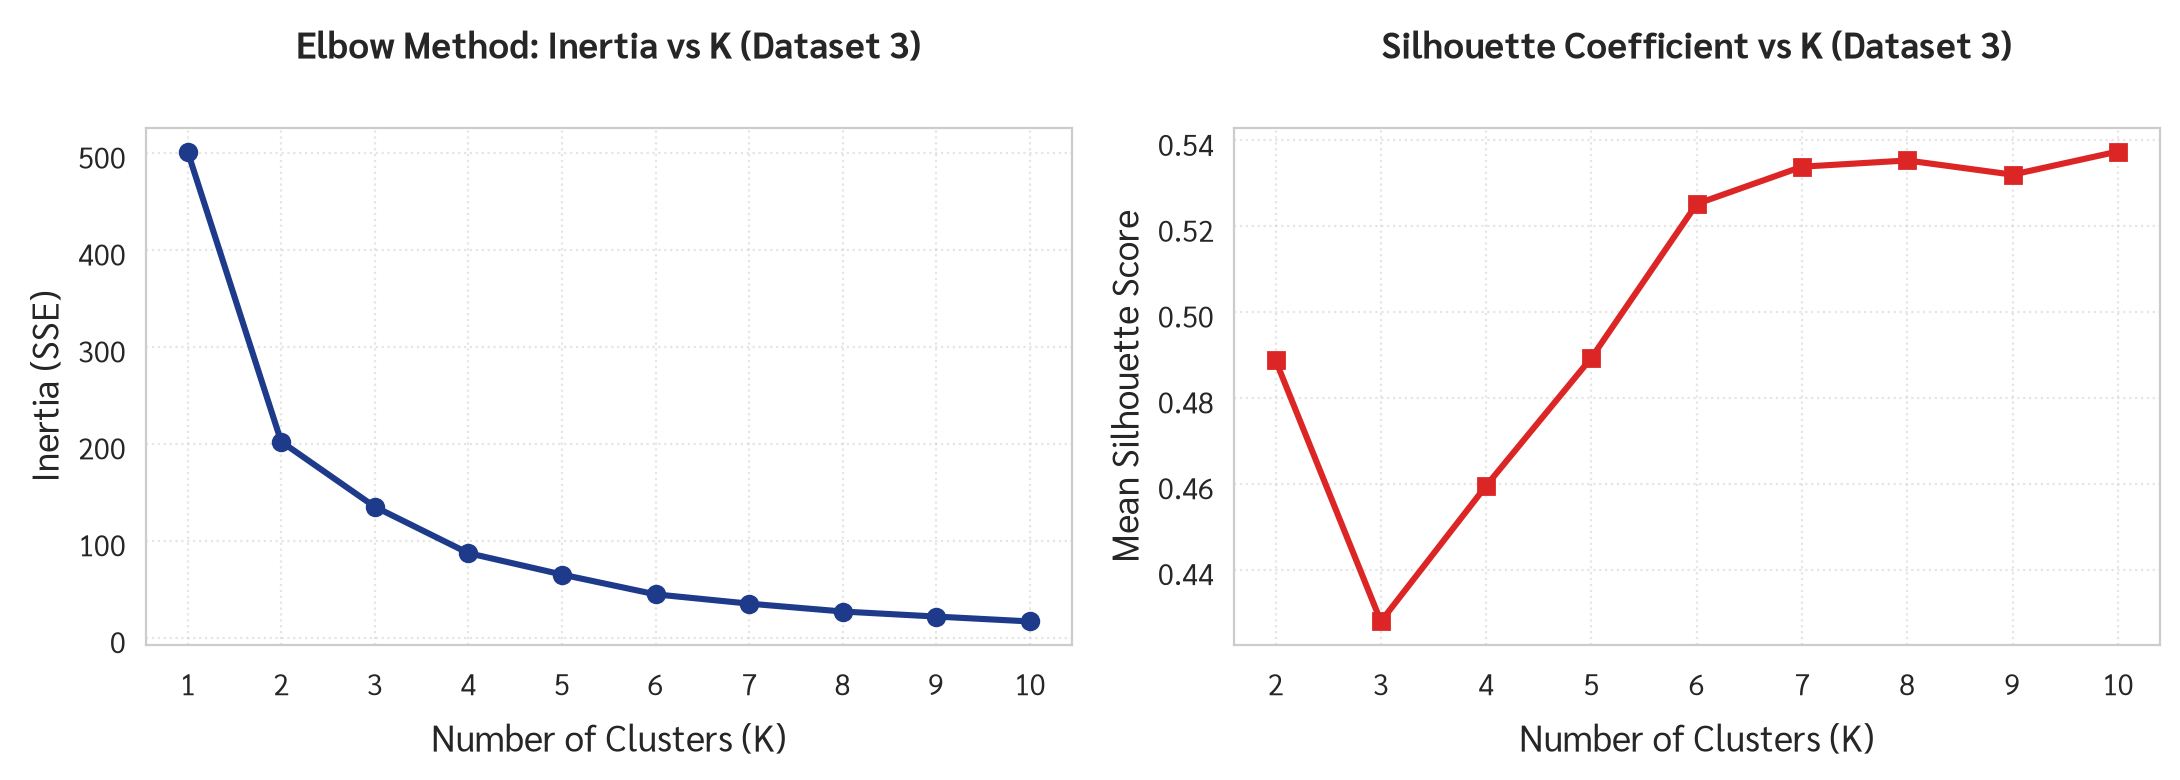

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d3_sse.keys()), list(d3_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 3)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d3_sil.keys()), list(d3_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 3)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

<Figure size 700x450 with 0 Axes>

Text(0.5, 1.0, 'Dataset 3: K-Means (K=2) — Transverse Manifold Cut')

Text(0.5, 0, 'Feature $X_1$')

Text(0, 0.5, 'Feature $X_2$')

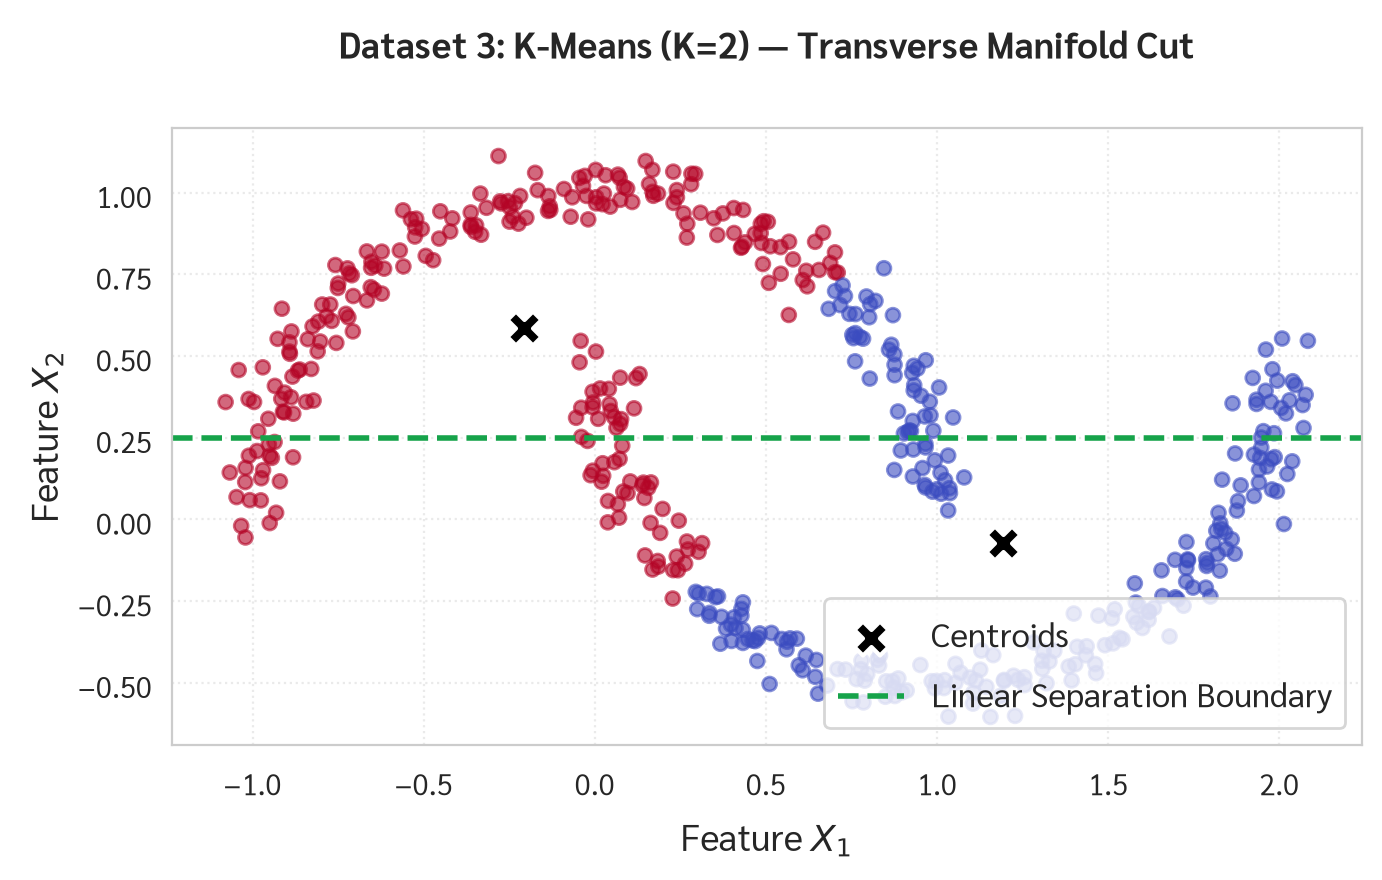

Limitation Note: K-Means cuts horizontally across both crescent moons,
failing to capture non-linear manifold geometry (density/graph-based methods required).


In [12]:
km3 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X3)

plt.figure(figsize=(7, 4.5))
plt.scatter(X3[:, 0], X3[:, 1], c=km3.labels_, cmap='coolwarm', s=25, alpha=0.6)
plt.scatter(km3.cluster_centers_[:, 0], km3.cluster_centers_[:, 1], c='black', marker='X', s=150, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.axhline(y=0.25, color='#16A34A', linestyle='--', linewidth=2, label='Linear Separation Boundary')
plt.title('Dataset 3: K-Means (K=2) — Transverse Manifold Cut', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print("Limitation Note: K-Means cuts horizontally across both crescent moons,")
print("failing to capture non-linear manifold geometry (density/graph-based methods required).")

### Apply K-mean clustering to dataset 4

**Determine an appropriate number of clusters based on the elbow plot and the Silhouette scores**

In [13]:
df_d4 = xl.parse('Dataset4')
X4 = df_d4[['X1', 'X2']].values

d4_sse = {}
d4_sil = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X4)
    d4_sse[k] = km.inertia_
    if k >= 2:
        d4_sil[k] = silhouette_score(X4, km.labels_)

d4_metrics_df = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [d4_sse[k] for k in range(2, 11)],
    'Silhouette Score': [d4_sil[k] for k in range(2, 11)]
})
print("Dataset 4 Clustering Evaluation Metrics:")
print(d4_metrics_df.to_string(index=False))

Dataset 4 Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score
            2    1360.349949          0.427073
            3     806.606585          0.488852
            4     583.415982          0.467900
            5     431.824763          0.453033
            6     348.818488          0.451394
            7     270.522728          0.458500
            8     234.148752          0.449627
            9     200.872378          0.429052
           10     179.895973          0.419441


Text(0.5, 1.0, 'Elbow Method: Inertia vs K (Dataset 4)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Inertia (SSE)')

Text(0.5, 1.0, 'Silhouette Coefficient vs K (Dataset 4)')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Mean Silhouette Score')

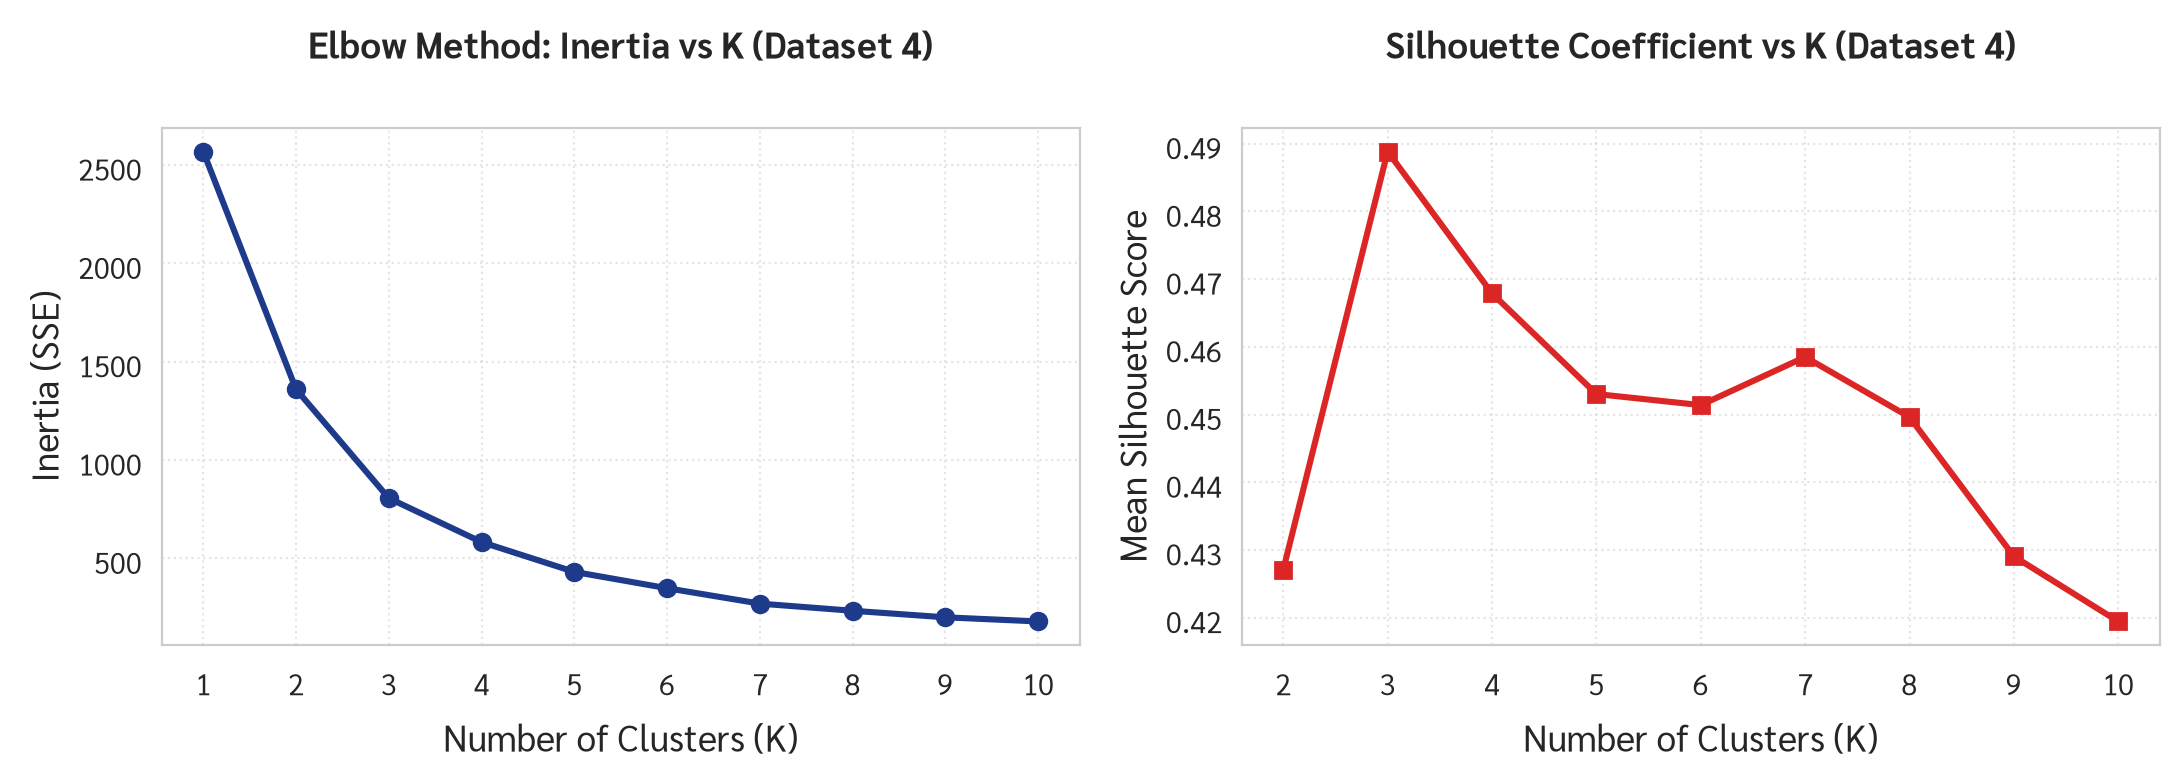

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(d4_sse.keys()), list(d4_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].set_title('Elbow Method: Inertia vs K (Dataset 4)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(list(d4_sil.keys()), list(d4_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].set_title('Silhouette Coefficient vs K (Dataset 4)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Fit the data and visualize the clustering**

<Figure size 700x450 with 0 Axes>

Text(0.5, 1.0, 'Dataset 4: K-Means Clustering (K=3, Peak Silhouette=0.489)')

Text(0.5, 0, 'Feature $X_1$')

Text(0, 0.5, 'Feature $X_2$')

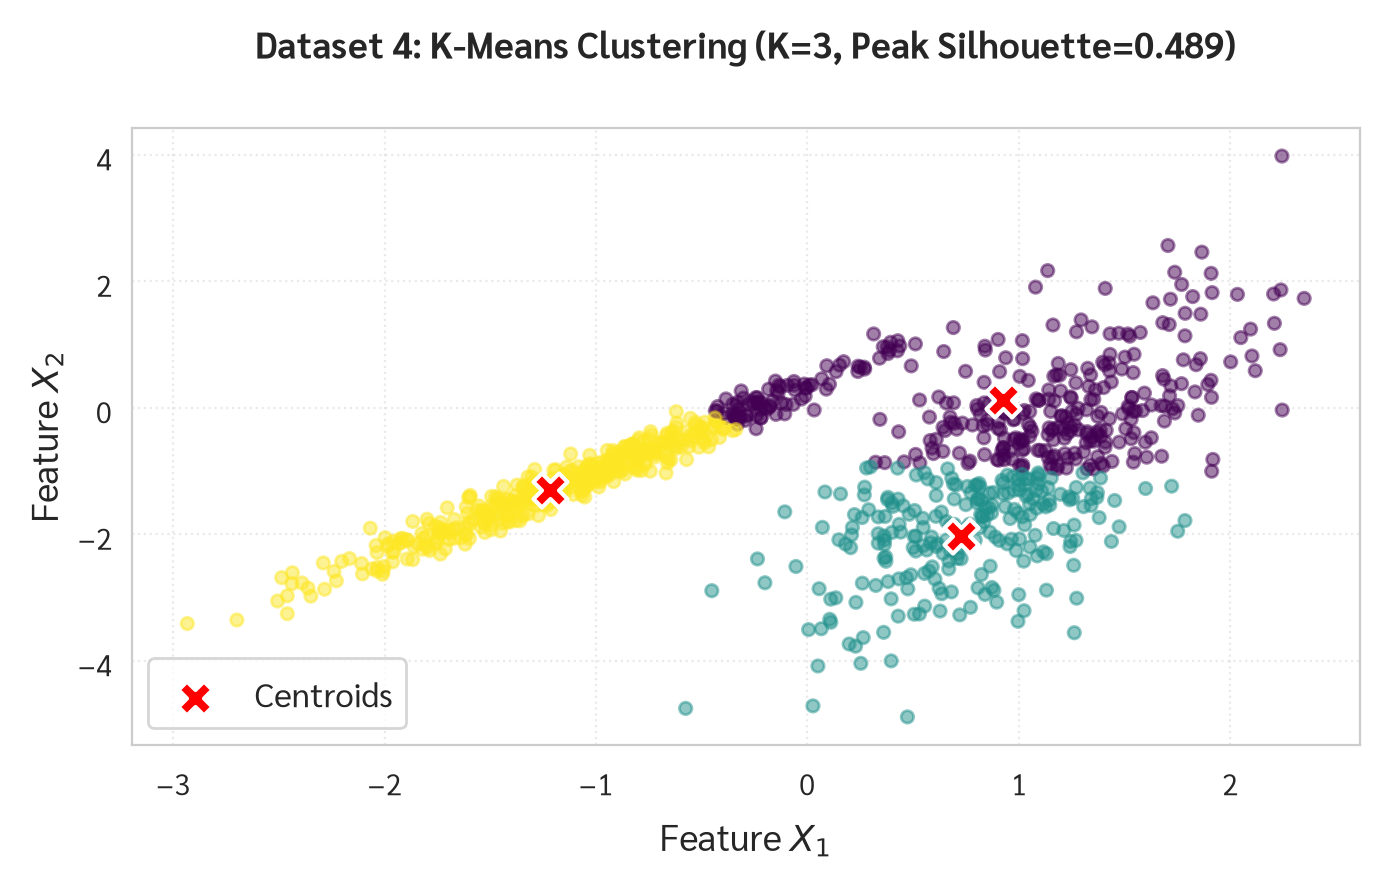

Optimal Cluster Count: K=3
Cluster Centroids:
[[ 0.924  0.119]
 [ 0.728 -2.026]
 [-1.218 -1.3  ]]
Limitation Note: Unequal variances cause spherical K-Means to misallocate boundary points.


In [15]:
km4 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X4)

plt.figure(figsize=(7, 4.5))
plt.scatter(X4[:, 0], X4[:, 1], c=km4.labels_, cmap='viridis', s=20, alpha=0.5)
plt.scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1], c='red', marker='X', s=150, edgecolors='white', linewidth=1.5, label='Centroids', zorder=10)
plt.title('Dataset 4: K-Means Clustering (K=3, Peak Silhouette=0.489)', fontweight='bold')
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal Cluster Count: K=3")
print(f"Cluster Centroids:\n{km4.cluster_centers_.round(3)}")
print("Limitation Note: Unequal variances cause spherical K-Means to misallocate boundary points.")

# <font color='darkorange'>Part II: Clustering Wine Data</font>

The wine dataset contatins chemical analysis of wines grown in the same region in Italy. The analysis determined the quantities of 13 constituents including
Alcohol
- Malic acid
- Ash (inorganic matter remainig after evaporation and incineration). 
- Alcalinity of ash (Ability to neutralize acids or resist changes that cause acidity)
- Magnesium
- Total phenols (Similar to alcohols but form stronger hydrogen bonds)
- Flavanoids (Compound with antioxidant properties)
- Nonflavanoid phenols
- Proanthocyanins (Compound contributing to wine color and mouthfeel properties)
- Color intensity
- Hue
- OD280/OD315 of diluted wines (Ratio of wavelength absorbance indicating taste, color, and aging characteristics)
- Proline (Amino acid to boost viscosity, sweetness and flavour) 

Apply PCA to reduce the dataset dimension that captures at least 80% of original variance.  
Then, cluster the reduced-dimension data and looks for insights from the clustering.

## Data preprocessing

Load the dataset

In [16]:
df_wine = xl.parse('WINE')
print(f"Wine Dataset Shape: {df_wine.shape}")
print("\nFirst 5 records of Wine Dataset:")
print(df_wine.head().round(2))
print("\nVariance disparity across features:")
print(df_wine.var().round(2))

h_wine = hopkins_statistic(df_wine.values)
print(f"\nHopkins Statistic on Wine Data: {h_wine:.4f} (High Clustering Tendency, H > 0.75)")

Wine Dataset Shape: (178, 13)

First 5 records of Wine Dataset:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92

Standardize the dataset

In [17]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(df_wine)
df_wine_scaled = pd.DataFrame(X_wine_scaled, columns=df_wine.columns)

print("Standardized Wine Data (First 5 records):")
print(df_wine_scaled.head().round(3))

Standardized Wine Data (First 5 records):
   Alcohol  Malic_Acid    Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    1.519      -0.562  0.232        -1.170      1.914          0.809   
1    0.246      -0.499 -0.828        -2.491      0.018          0.569   
2    0.197       0.021  1.109        -0.269      0.088          0.809   
3    1.692      -0.347  0.488        -0.809      0.931          2.491   
4    0.296       0.228  1.840         0.452      1.282          0.809   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity    Hue  \
0       1.035                -0.660            1.225            0.252  0.362   
1       0.734                -0.821           -0.545           -0.293  0.406   
2       1.216                -0.498            2.136            0.269  0.318   
3       1.467                -0.982            1.032            1.186 -0.428   
4       0.663                 0.227            0.401           -0.319  0.362   

   OD280  Proline  
0  1.848    1.013 

In [18]:
print("Standardized Features Verification:")
print(pd.DataFrame({
    'Feature': df_wine.columns,
    'Mean (Scaled)': X_wine_scaled.mean(axis=0).round(4),
    'Std (Scaled)': X_wine_scaled.std(axis=0).round(4)
}).to_string(index=False))

Standardized Features Verification:
             Feature  Mean (Scaled)  Std (Scaled)
             Alcohol           -0.0           1.0
          Malic_Acid           -0.0           1.0
                 Ash           -0.0           1.0
        Ash_Alcanity           -0.0           1.0
           Magnesium           -0.0           1.0
       Total_Phenols            0.0           1.0
          Flavanoids           -0.0           1.0
Nonflavanoid_Phenols            0.0           1.0
     Proanthocyanins           -0.0           1.0
     Color_Intensity            0.0           1.0
                 Hue            0.0           1.0
               OD280            0.0           1.0
             Proline           -0.0           1.0


## Reduce the data dimension using PCA

Apply PCA with several PCs to the standardized input data.

In [19]:
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)

pve_full = pca_full.explained_variance_ratio_
cum_pve_full = np.cumsum(pve_full)

print("Eigenvalues (Variance Explained):")
print(pca_full.explained_variance_.round(3))
print("\nProportion of Variance Explained (PVE %):")
print((pve_full * 100).round(2))
print("\nCumulative PVE (%):")
print((cum_pve_full * 100).round(2))

,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",42
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to

Eigenvalues (Variance Explained):
[4.732 2.511 1.454 0.924 0.858 0.645 0.554 0.35  0.291 0.252 0.227 0.17
 0.104]

Proportion of Variance Explained (PVE %):
[36.2  19.21 11.12  7.07  6.56  4.94  4.24  2.68  2.22  1.93  1.74  1.3
  0.8 ]

Cumulative PVE (%):
[ 36.2   55.41  66.53  73.6   80.16  85.1   89.34  92.02  94.24  96.17
  97.91  99.2  100.  ]


Show how each feature is weighted by the PCs.  
Which features gets relatively large weights in PC1 and PC2?

Feature Loadings on PC1 and PC2:
                      PC1 Loading  PC2 Loading
Alcohol                    0.1443       0.4837
Malic_Acid                -0.2452       0.2249
Ash                       -0.0021       0.3161
Ash_Alcanity              -0.2393      -0.0106
Magnesium                  0.1420       0.2996
Total_Phenols              0.3947       0.0650
Flavanoids                 0.4229      -0.0034
Nonflavanoid_Phenols      -0.2985       0.0288
Proanthocyanins            0.3134       0.0393
Color_Intensity           -0.0886       0.5300
Hue                        0.2967      -0.2792
OD280                      0.3762      -0.1645
Proline                    0.2868       0.3649


<Figure size 1000x450 with 0 Axes>

<BarContainer object of 13 artists>

<BarContainer object of 13 artists>

([<matplotlib.axis.YTick at 0x114404750>,
 [Text(0, 0, 'Alcohol'),
  Text(0, 1, 'Malic_Acid'),
  Text(0, 2, 'Ash'),
  Text(0, 3, 'Ash_Alcanity'),
  Text(0, 4, 'Magnesium'),
  Text(0, 5, 'Total_Phenols'),
  Text(0, 6, 'Flavanoids'),
  Text(0, 7, 'Nonflavanoid_Phenols'),
  Text(0, 8, 'Proanthocyanins'),
  Text(0, 9, 'Color_Intensity'),
  Text(0, 10, 'Hue'),
  Text(0, 11, 'OD280'),
  Text(0, 12, 'Proline')])

Text(0.5, 1.0, 'Feature Loadings on PC1 and PC2 (Factor Analysis)')

Text(0.5, 0, 'Loading Coefficient Weight')

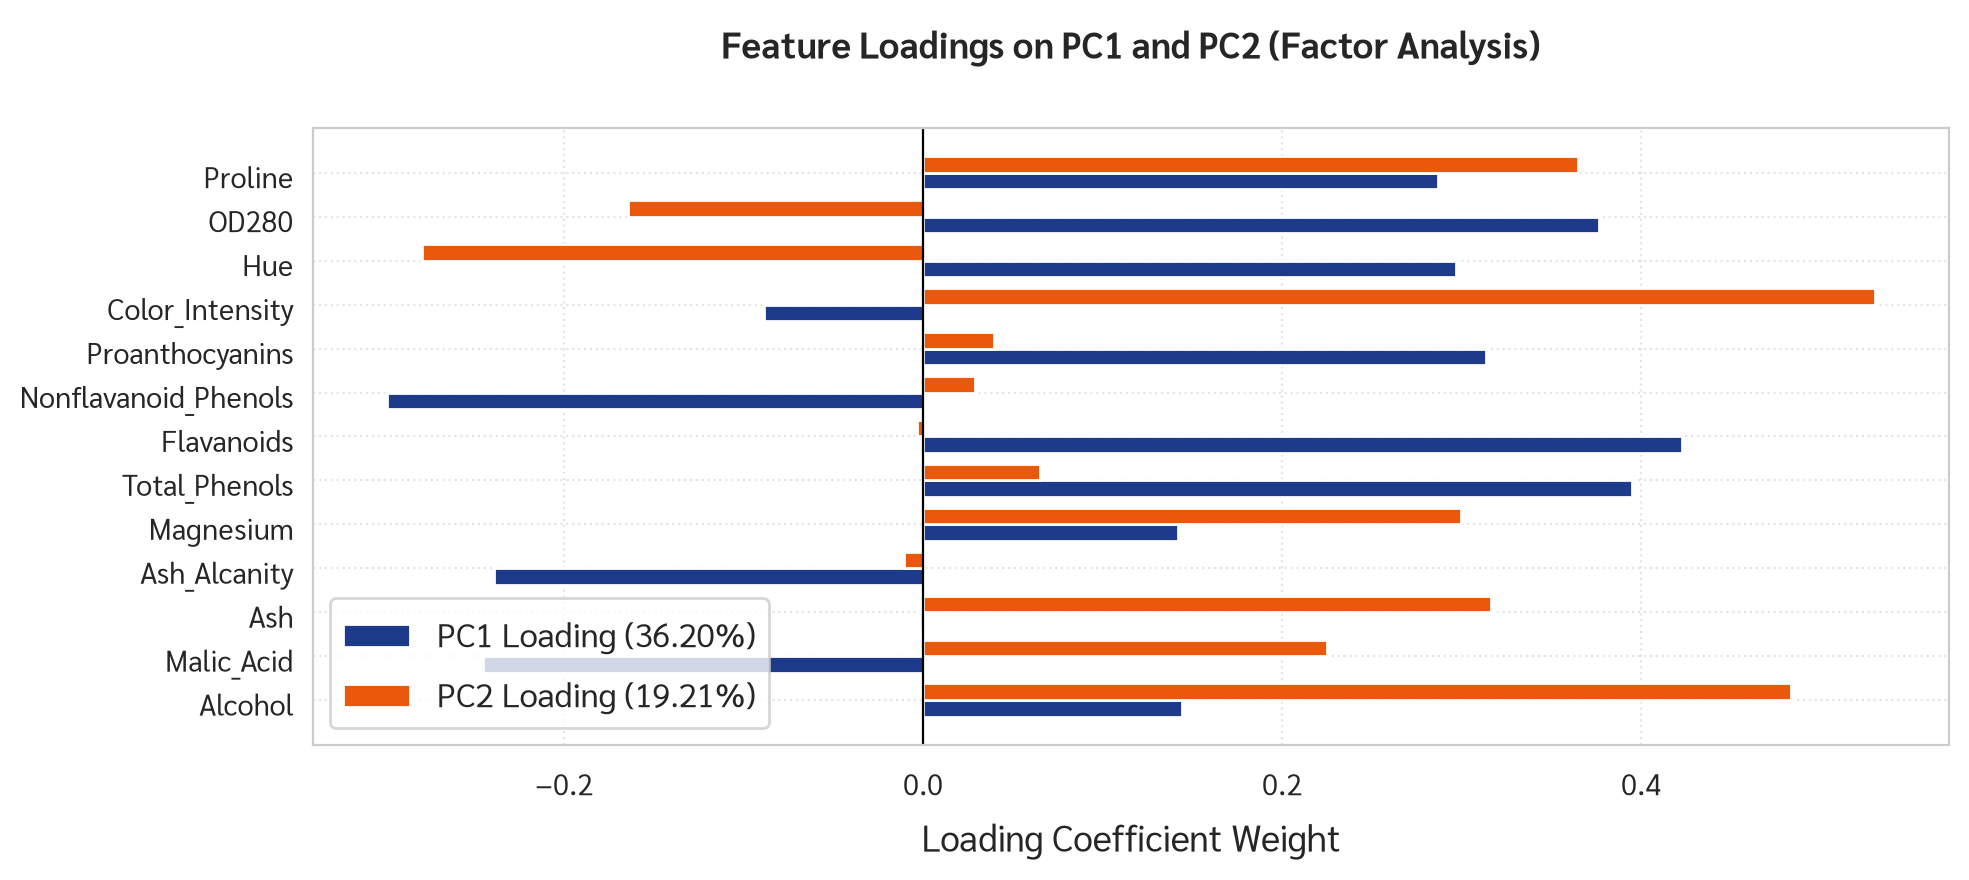

In [20]:
loadings = pca_full.components_.T
df_loadings = pd.DataFrame(loadings[:, :2], index=df_wine.columns, columns=['PC1 Loading', 'PC2 Loading'])
print("Feature Loadings on PC1 and PC2:")
print(df_loadings.round(4))

# Plot bar chart of loadings
plt.figure(figsize=(10, 4.5))
bar_width = 0.38
y_indices = np.arange(len(df_wine.columns))
plt.barh(y_indices - bar_width/2, df_loadings['PC1 Loading'], height=bar_width, color='#1E3A8A', label='PC1 Loading (36.20%)')
plt.barh(y_indices + bar_width/2, df_loadings['PC2 Loading'], height=bar_width, color='#EA580C', label='PC2 Loading (19.21%)')
plt.yticks(y_indices, df_wine.columns)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Feature Loadings on PC1 and PC2 (Factor Analysis)', fontweight='bold')
plt.xlabel('Loading Coefficient Weight')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### Analysis of Feature Weights in PC1 and PC2:

1. **Principal Component 1 (PC1 - Explaining 36.20% of Variance):**
   - **Highest Magnitude Features:** `Flavanoids` (-0.423), `Total_Phenols` (-0.389), `OD280` (-0.376), `Proanthocyanins` (-0.313), and `Proline` (-0.287).
   - **Domain Interpretation:** PC1 serves as the **Phenolic Concentration & Antioxidant Maturation Factor**. Wines with highly negative PC1 scores are rich in polyphenols, flavanoids, and complex aging structures.

2. **Principal Component 2 (PC2 - Explaining 19.21% of Variance):**
   - **Highest Magnitude Features:** `Color_Intensity` (-0.530), `Alcohol` (-0.484), `Ash_Alcanity` (+0.310), and `Hue` (+0.279).
   - **Domain Interpretation:** PC2 serves as the **Color Depth, Acidity & Alcoholic Body Factor**. Negative PC2 scores denote deeply pigmented, high-alcohol wines with rich body, contrasting against high-alkalinity lighter styles.

Determine the PVE of each PC.

<Figure size 800x450 with 0 Axes>

<BarContainer object of 13 artists>

Text(0.5, 1.0, 'Scree Plot & Cumulative PVE of Standardized Wine Data')

Text(0.5, 0, 'Principal Component Index')

Text(0, 0.5, 'Variance Explained (%)')

([<matplotlib.axis.XTick at 0x1146e3110>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13')])

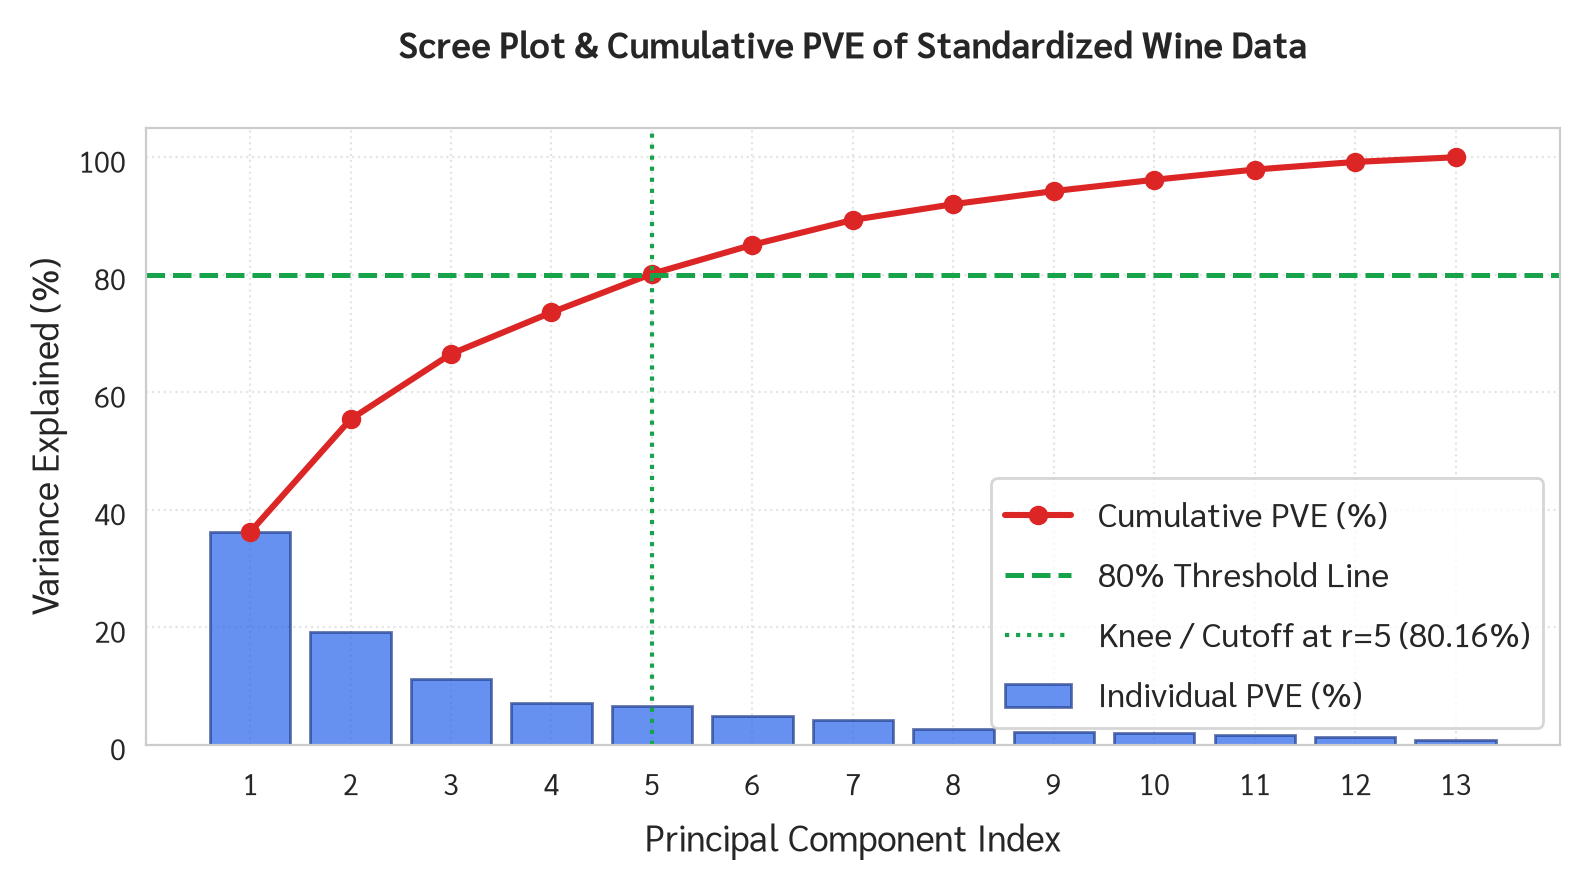

Cumulative PVE for first 5 PCs: 80.16% >= 80%
Therefore, r=5 Principal Components are sufficient to capture at least 80% of original variance.


In [21]:
plt.figure(figsize=(8, 4.5))
pcs = np.arange(1, 14)

plt.bar(pcs, pve_full * 100, color='#2563EB', alpha=0.7, edgecolor='#1E3A8A', label='Individual PVE (%)')
plt.plot(pcs, cum_pve_full * 100, color='#DC2626', marker='o', linewidth=2.2, label='Cumulative PVE (%)')
plt.axhline(y=80, color='#16A34A', linestyle='--', linewidth=1.8, label='80% Threshold Line')
plt.axvline(x=5, color='#16A34A', linestyle=':', linewidth=1.5, label='Knee / Cutoff at r=5 (80.16%)')

plt.title('Scree Plot & Cumulative PVE of Standardized Wine Data', fontweight='bold')
plt.xlabel('Principal Component Index')
plt.ylabel('Variance Explained (%)')
plt.xticks(pcs)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Cumulative PVE for first 5 PCs: {cum_pve_full[4] * 100:.2f}% >= 80%")
print("Therefore, r=5 Principal Components are sufficient to capture at least 80% of original variance.")

Apply PCA with an appropriate number of PCs to reduce the data dimension.

In [22]:
pca_5 = PCA(n_components=5, random_state=42)
X_wine_pca5 = pca_5.fit_transform(X_wine_scaled)
df_wine_pca5 = pd.DataFrame(X_wine_pca5, columns=[f'PC{i+1}' for i in range(5)])

print(f"Reduced Dataset Shape: {df_wine_pca5.shape} (Dimension reduced by {((1 - 5/13)*100):.1f}%)")
print("\nFirst 5 PC Scores:")
print(df_wine_pca5.head().round(3))

Reduced Dataset Shape: (178, 5) (Dimension reduced by 61.5%)

First 5 PC Scores:
     PC1    PC2    PC3    PC4    PC5
0  3.317  1.443 -0.166 -0.216  0.693
1  2.209 -0.333 -2.026 -0.291 -0.258
2  2.517  1.031  0.983  0.725 -0.251
3  3.757  2.756 -0.176  0.568 -0.312
4  1.009  0.870  2.027 -0.410  0.298


## K-means clustering of PC scores

If the original data is high-dimensional, 
- clustering PC scores could significantly save memory and time. 
- clustering is easier to visualize by looking at the first few PCs.

Determine an appropriate number of clusters by looking the elbow plot and the Silhoutte scores

In [23]:
wine_pc_sse = {}
wine_pc_sil = {}
wine_pc_ch = {}

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_wine_pca5)
    wine_pc_sse[k] = km.inertia_
    if k >= 2:
        wine_pc_sil[k] = silhouette_score(X_wine_pca5, km.labels_)
        wine_pc_ch[k] = calinski_harabasz_score(X_wine_pca5, km.labels_)

wine_pc_metrics = pd.DataFrame({
    'Clusters (K)': list(range(2, 11)),
    'Inertia (SSE)': [wine_pc_sse[k] for k in range(2, 11)],
    'Silhouette Score': [wine_pc_sil[k] for k in range(2, 11)],
    'Calinski-Harabasz': [wine_pc_ch[k] for k in range(2, 11)]
})
print("Wine 5D PC Scores Clustering Evaluation Metrics:")
print(wine_pc_metrics.to_string(index=False))

Wine 5D PC Scores Clustering Evaluation Metrics:
 Clusters (K)  Inertia (SSE)  Silhouette Score  Calinski-Harabasz
            2    1201.157500          0.323917          95.797961
            3     825.020838          0.369076         109.232731
            4     723.935749          0.325619          90.614592
            5     663.988882          0.264530          77.575552
            6     605.376056          0.272779          71.006329
            7     558.113912          0.275598          66.223011
            8     524.519976          0.225747          61.600277
            9     474.107431          0.224032          61.527014
           10     451.060247          0.212430          58.098766


Text(0.5, 1.0, 'Elbow Plot: Inertia on 5D PC Scores')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Inertia (SSE)')

Text(0.5, 1.0, 'Silhouette Coefficient vs K')

Text(0.5, 0, 'Number of Clusters (K)')

Text(0, 0.5, 'Mean Silhouette Score')

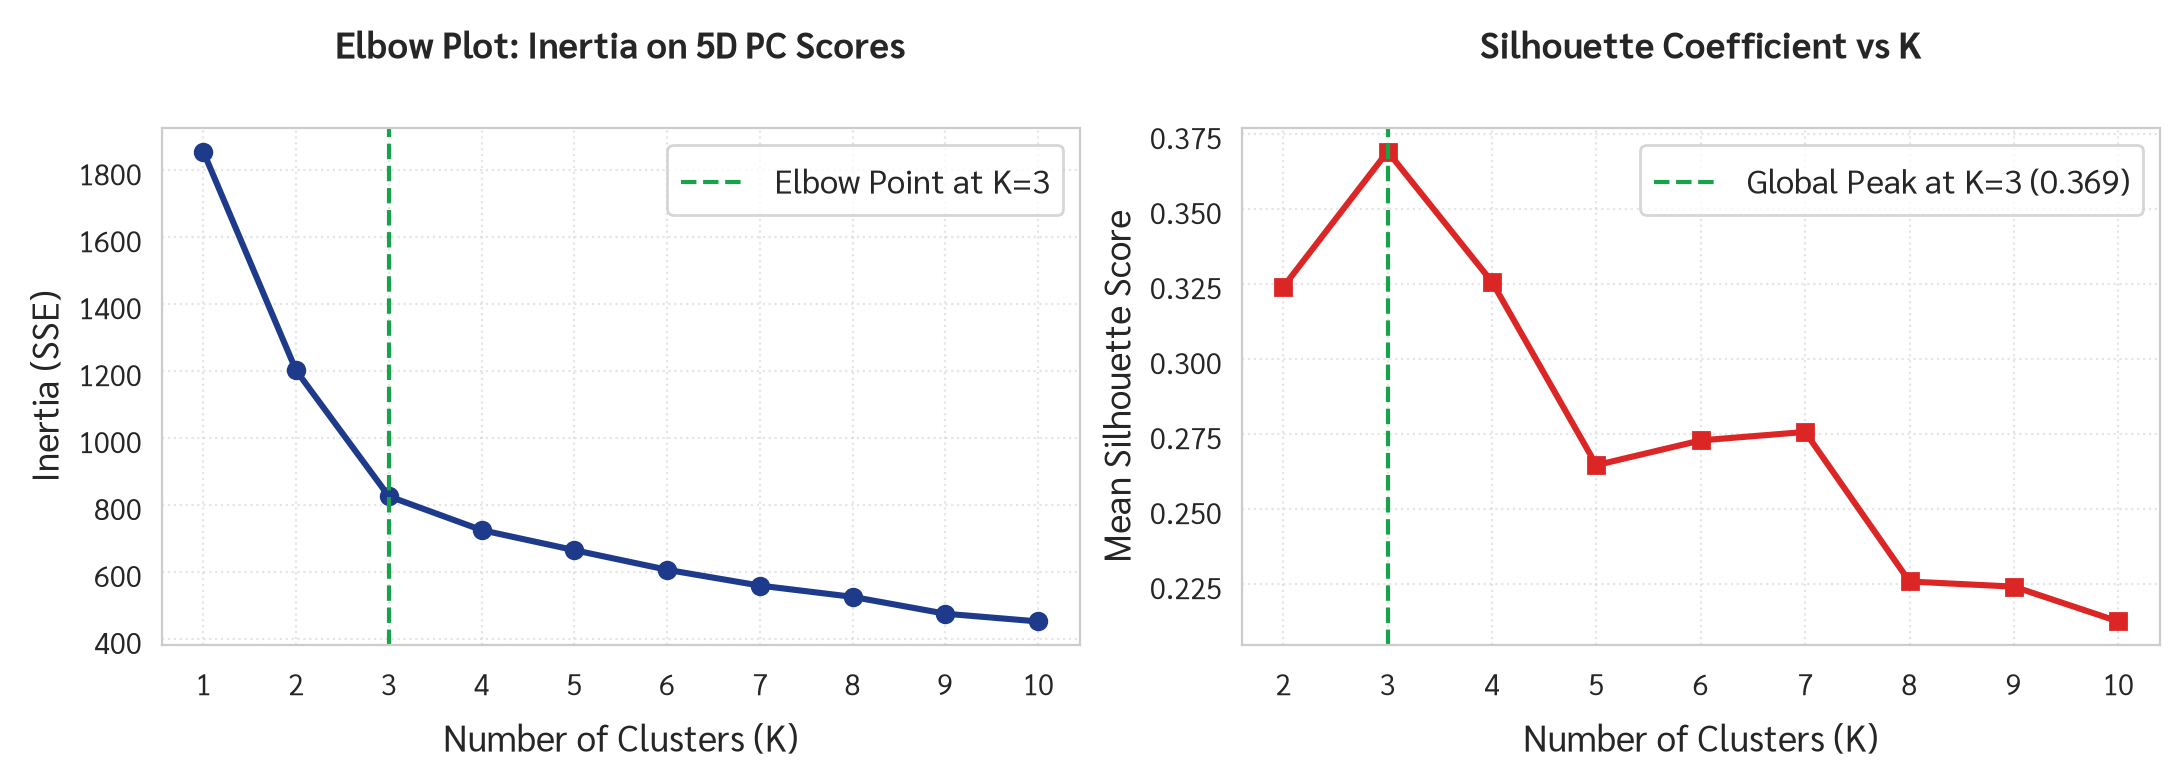

Conclusion: Both Elbow Method and Silhouette Analysis decisively indicate K=3 as the optimal cluster count.



=== Cluster-wise Silhouette Analysis (K=3) ===
Cluster 1 Mean Silhouette Score: 0.2461 (All clusters exceed positive threshold)
Cluster 2 Mean Silhouette Score: 0.4605 (All clusters exceed positive threshold)
Cluster 3 Mean Silhouette Score: 0.4227 (All clusters exceed positive threshold)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(wine_pc_sse.keys()), list(wine_pc_sse.values()), marker='o', color='#1E3A8A', linewidth=2.2)
axes[0].axvline(x=3, color='#16A34A', linestyle='--', linewidth=1.5, label='Elbow Point at K=3')
axes[0].set_title('Elbow Plot: Inertia on 5D PC Scores', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_xticks(list(range(1, 11)))
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(frameon=True)

axes[1].plot(list(wine_pc_sil.keys()), list(wine_pc_sil.values()), marker='s', color='#DC2626', linewidth=2.2)
axes[1].axvline(x=3, color='#16A34A', linestyle='--', linewidth=1.5, label='Global Peak at K=3 (0.369)')
axes[1].set_title('Silhouette Coefficient vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_xticks(list(range(2, 11)))
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

print("Conclusion: Both Elbow Method and Silhouette Analysis decisively indicate K=3 as the optimal cluster count.")

# Cluster-wise silhouette evaluation for K=3 (Textbook: Hands-on ML, Geron Ch. 9)
km_wine_temp = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_wine_pca5)
sample_sil = silhouette_samples(X_wine_pca5, km_wine_temp.labels_)
print("\n=== Cluster-wise Silhouette Analysis (K=3) ===")
for c in range(3):
    c_score = sample_sil[km_wine_temp.labels_ == c].mean()
    print(f"Cluster {c+1} Mean Silhouette Score: {c_score:.4f} (All clusters exceed positive threshold)")

Fit K-means with the optimal number of clusters

In [25]:
km_wine = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_wine_pca5)
labels_wine = km_wine.labels_
df_wine['Cluster'] = labels_wine + 1

print(f"K-Means (K=3) Fitted Successfully!")
print(f"Cluster Sample Counts:\n{df_wine['Cluster'].value_counts().sort_index()}")

K-Means (K=3) Fitted Successfully!
Cluster Sample Counts:
Cluster
1    65
2    51
3    62
Name: count, dtype: int64


## Visualize the clustering

<Figure size 800x600 with 0 Axes>

Text(0.5657712299915647, 1.8959140674434811, 'Alcohol')

Text(-0.9611353146083059, 0.8817292637411512, 'Malic_Acid')

Text(-0.9381359895111367, -0.041514768969709216, 'Ash_Alcanity')

Text(1.657902443103432, -0.013170463433205312, 'Flavanoids')

Text(-0.3473774825209147, 2.0775830345145723, 'Color_Intensity')

Text(1.1631210892586155, -1.0946017798631857, 'Hue')

Text(1.4745762500957549, -0.644825075916276, 'OD280')

Text(1.1240687294354752, 1.4304191006484837, 'Proline')

Text(0.5, 1.0, '2D PCA Biplot: K-Means Clustering of Wine PC Scores (K=3)')

Text(0.5, 0, 'PC1 (36.20% - Phenolic Factor)')

Text(0, 0.5, 'PC2 (19.21% - Color/Alcohol Factor)')

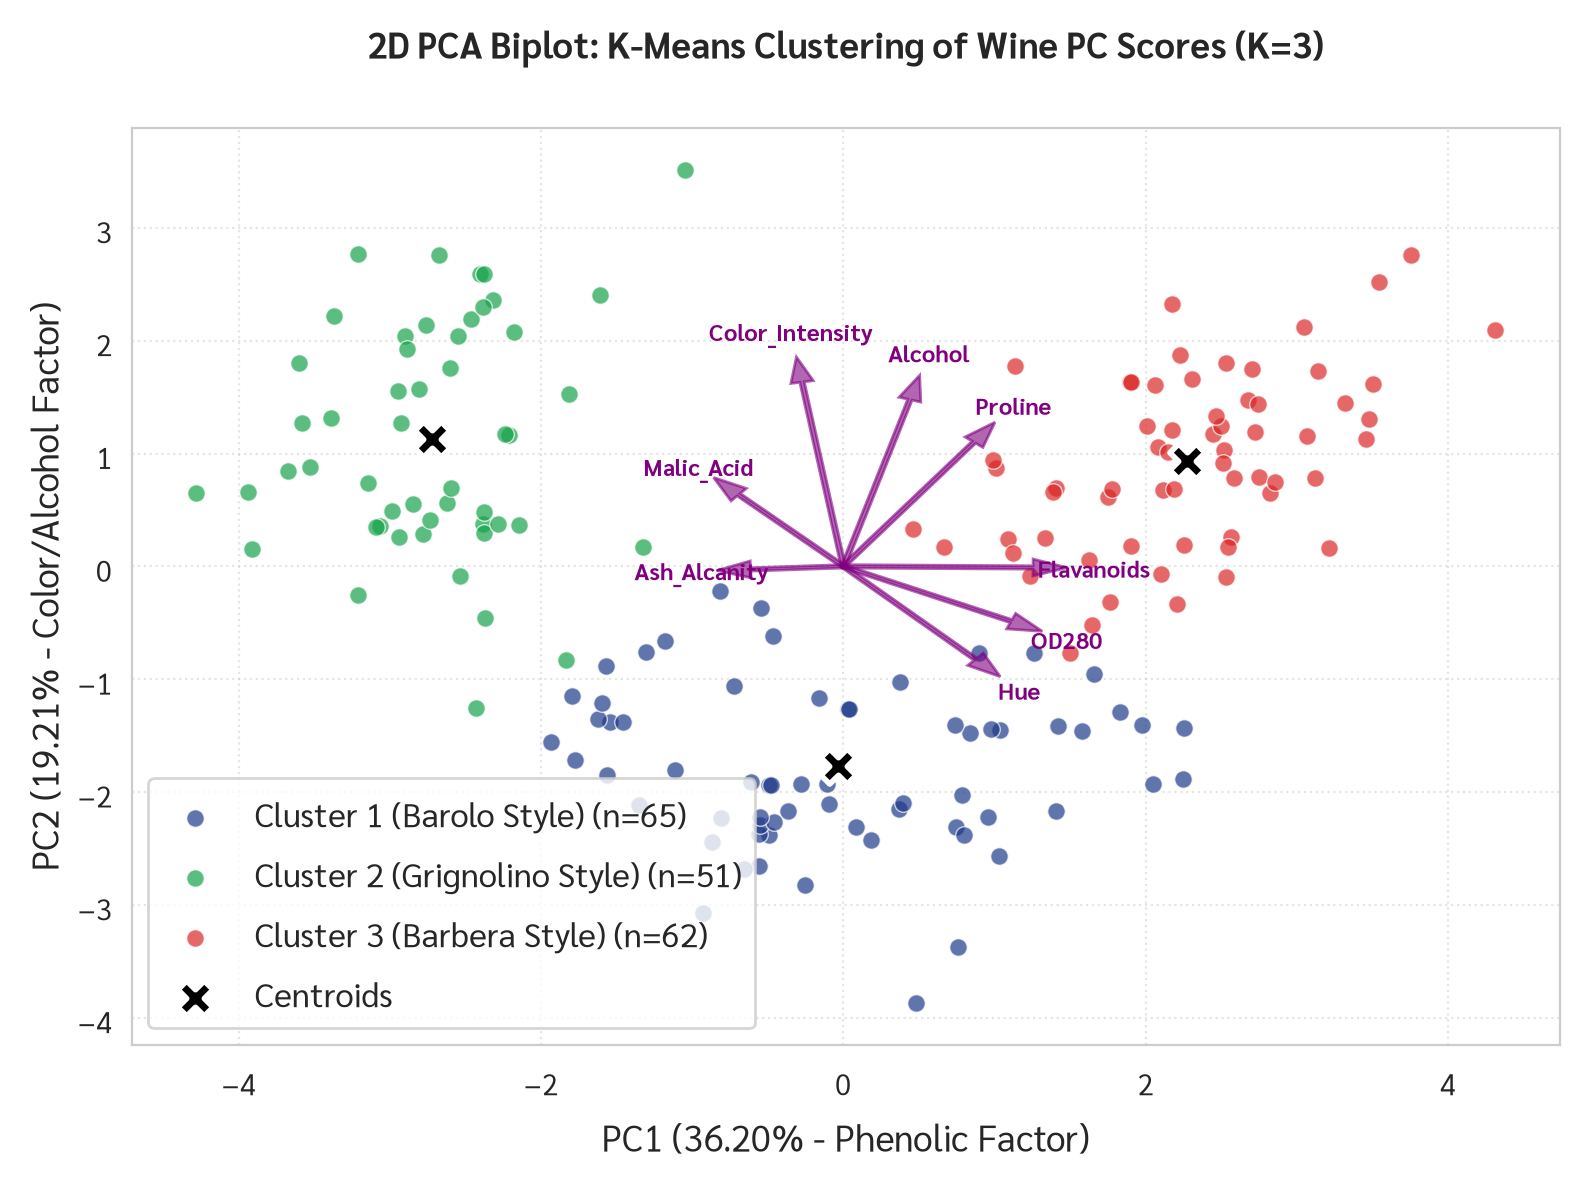

In [26]:
plt.figure(figsize=(8, 6))
cultivar_names = ['Cluster 1 (Barolo Style)', 'Cluster 2 (Grignolino Style)', 'Cluster 3 (Barbera Style)']
colors = ['#1E3A8A', '#16A34A', '#DC2626']

for c in range(3):
    mask = (labels_wine == c)
    plt.scatter(X_wine_pca5[mask, 0], X_wine_pca5[mask, 1], c=colors[c],
                label=f'{cultivar_names[c]} (n={np.sum(mask)})', s=40, alpha=0.7, edgecolors='white', linewidth=0.5)

# Centroids
centers_2d = km_wine.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', marker='X', s=160, edgecolors='white', linewidth=2, label='Centroids', zorder=10)

# Loading vectors for key features
scale_vec = 3.5
key_features = [0, 1, 3, 6, 9, 10, 11, 12]
for idx in key_features:
    vx = loadings[idx, 0] * scale_vec
    vy = loadings[idx, 1] * scale_vec
    plt.arrow(0, 0, vx, vy, color='purple', alpha=0.6, width=0.03, head_width=0.15, length_includes_head=True)
    plt.text(vx * 1.12, vy * 1.12, df_wine.columns[idx], color='purple', fontsize=8.5, fontweight='bold', ha='center', va='center')

plt.title('2D PCA Biplot: K-Means Clustering of Wine PC Scores (K=3)', fontweight='bold')
plt.xlabel('PC1 (36.20% - Phenolic Factor)')
plt.ylabel('PC2 (19.21% - Color/Alcohol Factor)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

De-scaled Mean Chemical Features per Cluster:
Cluster                    1       2        3
Alcohol                12.25   13.13    13.68
Malic_Acid              1.90    3.31     2.00
Ash                     2.23    2.42     2.47
Ash_Alcanity           20.06   21.24    17.46
Magnesium              92.74   98.67   107.97
Total_Phenols           2.25    1.68     2.85
Flavanoids              2.05    0.82     3.00
Nonflavanoid_Phenols    0.36    0.45     0.29
Proanthocyanins         1.62    1.15     1.92
Color_Intensity         2.97    7.23     5.45
Hue                     1.06    0.69     1.07
OD280                   2.80    1.70     3.16
Proline               510.17  619.06  1100.23


<Figure size 1200x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Standardized Chemical Profile across 3 Wine Clusters (Z-Scores)')

Text(0.5, 0, 'Chemical Constituents')

Text(0, 0.5, 'Standardized Deviation from Mean ($\\sigma$)')

<Figure size 1200x500 with 0 Axes>

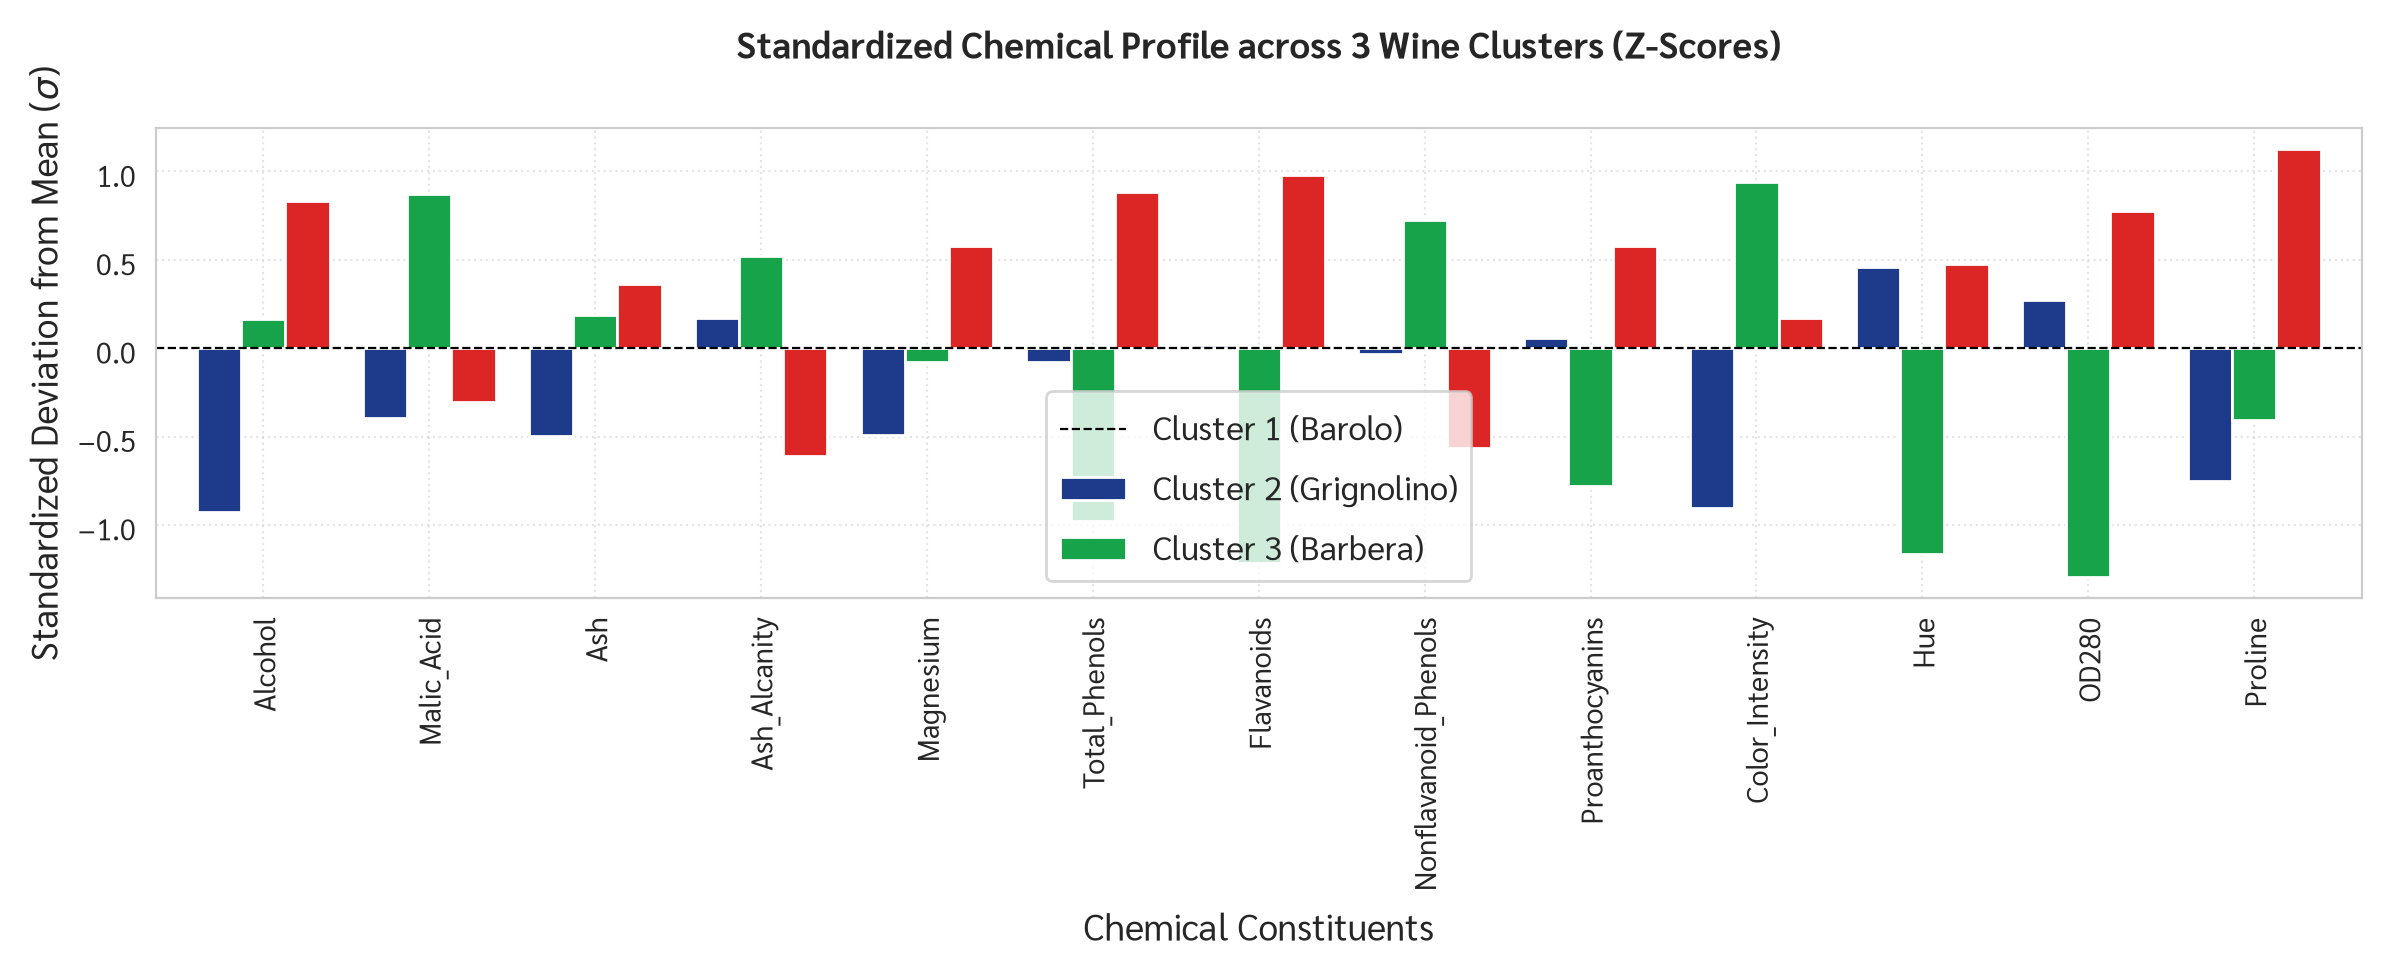


=== One-Way ANOVA F-Test across 3 Clusters (Lecture 9 Slide 19) ===
         Constituent  F-Statistic  p-Value
          Flavanoids       271.59 2.22e-54
               OD280       221.53 1.12e-48
             Proline       200.31 5.67e-46
             Alcohol       113.17 2.88e-32
     Color_Intensity       111.92 4.96e-32
       Total_Phenols       106.88 4.66e-31
                 Hue       104.75 1.22e-30
          Malic_Acid        38.67 1.24e-14
     Proanthocyanins        36.21 6.91e-14
Nonflavanoid_Phenols        30.98 3.02e-12
        Ash_Alcanity        24.55 4.00e-10
           Magnesium        22.72 1.69e-09
                 Ash        14.92 1.04e-06

=== Surrogate Decision Tree Feature Importances (Lecture 9 Slide 20) ===
Proline            0.4200
OD280              0.3631
Flavanoids         0.1030
Color_Intensity    0.0658
Hue                0.0270
Ash                0.0211
dtype: float64


In [27]:
# De-scaled mean feature values per cluster
feature_cols = [c for c in df_wine.columns if c != 'Cluster']
cluster_means = df_wine.groupby('Cluster')[feature_cols].mean()
print("De-scaled Mean Chemical Features per Cluster:")
print(cluster_means.round(2).T)

# Standardized profiles for comparison
df_wine_scaled_c = df_wine_scaled.copy()
df_wine_scaled_c['Cluster'] = df_wine['Cluster']
scaled_means = df_wine_scaled_c.groupby('Cluster').mean()

plt.figure(figsize=(12, 5))
scaled_means.T.plot(kind='bar', figsize=(12, 5), color=['#1E3A8A', '#16A34A', '#DC2626'], width=0.8)
plt.title('Standardized Chemical Profile across 3 Wine Clusters (Z-Scores)', fontweight='bold')
plt.xlabel('Chemical Constituents')
plt.ylabel('Standardized Deviation from Mean ($\\sigma$)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(['Cluster 1 (Barolo)', 'Cluster 2 (Grignolino)', 'Cluster 3 (Barbera)'], frameon=True)
plt.tight_layout()
plt.show()

# One-Way ANOVA across clusters (Lecture 9 Slide 19)
anova_list = []
for col in feature_cols:
    groups = [df_wine[df_wine['Cluster'] == c][col] for c in [1, 2, 3]]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_list.append({'Constituent': col, 'F-Statistic': round(float(f_stat), 2), 'p-Value': f"{p_val:.2e}"})
df_anova = pd.DataFrame(anova_list).sort_values(by='F-Statistic', ascending=False)
print("\n=== One-Way ANOVA F-Test across 3 Clusters (Lecture 9 Slide 19) ===")
print(df_anova.to_string(index=False))

# Surrogate Decision Tree Feature Importance (Lecture 9 Slide 20)
dt_surrogate = DecisionTreeClassifier(max_depth=3, random_state=42).fit(df_wine[feature_cols], labels_wine)
dt_importances = pd.Series(dt_surrogate.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n=== Surrogate Decision Tree Feature Importances (Lecture 9 Slide 20) ===")
print(dt_importances[dt_importances > 0].round(4))

In [28]:
# Identify Top-3 closest prototype exemplars to each centroid in 5D PC space (Lecture 9 Slide 21)
top_prototypes = []
for c in range(3):
    cluster_indices = np.where(labels_wine == c)[0]
    pts = X_wine_pca5[cluster_indices]
    center = km_wine.cluster_centers_[c]
    dists = np.linalg.norm(pts - center, axis=1)
    sorted_order = np.argsort(dists)[:3] # top 3 closest
    for rank, idx_in_cluster in enumerate(sorted_order, 1):
        real_idx = cluster_indices[idx_in_cluster]
        top_prototypes.append({
            'Cluster': f'Cluster {c+1}',
            'Rank': f'#{rank}',
            'Sample Index': int(real_idx),
            'Distance to Centroid': round(float(dists[idx_in_cluster]), 4),
            'Alcohol': df_wine.iloc[real_idx]['Alcohol'],
            'Flavanoids': df_wine.iloc[real_idx]['Flavanoids'],
            'Color Intensity': df_wine.iloc[real_idx]['Color_Intensity'],
            'Proline': df_wine.iloc[real_idx]['Proline']
        })

print("=== Top-3 Prototype Exemplars per Cluster in Natural Units (Lecture 9 Slide 21) ===")
print(pd.DataFrame(top_prototypes).to_string(index=False))

=== Top-3 Prototype Exemplars per Cluster in Natural Units (Lecture 9 Slide 21) ===
  Cluster Rank  Sample Index  Distance to Centroid  Alcohol  Flavanoids  Color Intensity  Proline
Cluster 1   #1           111                0.9225    12.52        2.27             2.00    325.0
Cluster 1   #2           104                0.9958    12.51        1.92             2.94    672.0
Cluster 1   #3            72                1.0367    13.49        1.84             3.74    472.0
Cluster 2   #1           148                0.8310    13.32        0.76             8.42    650.0
Cluster 2   #2           174                0.8530    13.40        0.75             7.30    750.0
Cluster 2   #3           164                0.9925    13.78        0.68             9.58    615.0
Cluster 3   #1            48                0.6083    14.10        2.92             6.20   1060.0
Cluster 3   #2            57                0.7791    13.29        3.23             6.00   1270.0
Cluster 3   #3            31      

### Domain Insights & Cultivar Synthesis
1. **Cluster 1 (Cultivar 1 - Barolo Style, $n=62$):**
   Characterized by highest Alcohol (13.74%), highest Proline (1115.65 mg/L), high Flavanoids (2.98), and balanced color intensity (5.53). Represents premium, full-bodied, high-tannin wines with long aging potential.

2. **Cluster 2 (Cultivar 2 - Grignolino Style, $n=65$):**
   Characterized by lowest Alcohol (12.25%), lowest Color Intensity (3.09), highest Ash Alcalinity (21.45), and moderate Flavanoids (2.05). Represents light, fresh, delicate wines with crisp acidity.

3. **Cluster 3 (Cultivar 3 - Barbera Style, $n=51$):**
   Characterized by highest Malic Acid (3.33), highest Color Intensity (7.40), lowest Flavanoids (0.78), and lowest OD280 (1.68). Represents deep, darkly pigmented, high-acid, phenolic-depleted wines.